In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt 
import matplotlib as mpl
import seaborn as sns

from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split, GroupShuffleSplit 

import glob, sys, os, math, gc, sklearn, scipy 
from scipy.stats import iqr

print(f'Tensorflow V{tf.__version__}')
print(f'Keras V{tf.keras.__version__}')
print(f'Python V{sys.version}') 

2026-01-18 21:07:31.468737: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768770451.645248      26 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768770451.696790      26 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768770452.140303      26 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768770452.140350      26 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768770452.140353      26 computation_placer.cc:177] computation placer alr

Tensorflow V2.19.0
Keras V3.10.0
Python V3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [2]:
tf.config.run_functions_eagerly(True)

In [3]:
# MatplotLib Global Settings
mpl.rcParams.update(mpl.rcParamsDefault)
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['axes.labelsize'] = 18
mpl.rcParams['axes.titlesize'] = 24 

In [4]:
# If True, processing data from scratch
# If False, loads preprocessed data
PREPROCESS_DATA = True  # Set to True if first run with aug
TRAIN_MODEL = True
# True: use 10% of participants as validation set
# False: use all data for training -> gives better LB result
USE_VAL = True  # Enable for early stopping

N_ROWS = 543
N_DIMS = 3
DIM_NAMES = ['x', 'y', 'z']
SEED = 42
NUM_CLASSES = 250
IS_INTERACTIVE = os.environ['KAGGLE_KERNEL_RUN_TYPE'] == 'Interactive'
VERBOSE = 1 if IS_INTERACTIVE else 2

INPUT_SIZE = 64

BATCH_ALL_SIGNS_N = 4
BATCH_SIZE = 64 
N_EPOCHS = 50 # 100
LR_MAX = 1e-3
N_WARMUP_EPOCHS = 0
WD_RATIO = 0.05
MASK_VAL = 4237

In [5]:
# Prints Shape and Dtype For List Of Variables
def print_shape_dtype(l, names):
    for e, n in zip(l, names):
        print(f'{n} shape: {e.shape}, dtype: {e.dtype}') 

In [6]:
# Read Training Data
#if IS_INTERACTIVE or not PREPROCESS_DATA:
    #train = pd.read_csv('/kaggle/input/asl-signs/train.csv').sample(int(5e3), random_state=SEED)
#else:
train = pd.read_csv('/kaggle/input/asl-signs/train.csv')

N_SAMPLES = len(train)
print(f'N_SAMPLES: {N_SAMPLES}') 

N_SAMPLES: 94477


In [7]:
# Get complete file path to file
def get_file_path(path):
    return f'/kaggle/input/asl-signs/{path}'

train['file_path'] = train['path'].apply(get_file_path) 

# Ordinally Encode Sign

In [8]:
# Add ordinally Encoded Sign (assign number to each sign name)
train['sign_ord'] = train['sign'].astype('category').cat.codes

# Dictionaries to translate sign to ordinal encoded sign
SIGN2ORD = train[['sign', 'sign_ord']].set_index('sign').squeeze().to_dict()
ORD2SIGN = train[['sign_ord', 'sign']].set_index('sign_ord').squeeze().to_dict() 

In [9]:
display(train.sample(n=5)) 
display(train.info()) 

,path,participant_id,sequence_id,sign,file_path,sign_ord
46375,train_landmark_files/16069/2894025246.parquet,16069,2894025246,pig,/kaggle/input/asl-signs/train_landmark_files/1...,171
31036,train_landmark_files/34503/227252520.parquet,34503,227252520,can,/kaggle/input/asl-signs/train_landmark_files/3...,35
42525,train_landmark_files/25571/2739084074.parquet,25571,2739084074,wake,/kaggle/input/asl-signs/train_landmark_files/2...,233
55643,train_landmark_files/29302/3276534224.parquet,29302,3276534224,boy,/kaggle/input/asl-signs/train_landmark_files/2...,29
6331,train_landmark_files/55372/1261347906.parquet,55372,1261347906,chin,/kaggle/input/asl-signs/train_landmark_files/5...,43


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94477 entries, 0 to 94476
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   path            94477 non-null  object
 1   participant_id  94477 non-null  int64 
 2   sequence_id     94477 non-null  int64 
 3   sign            94477 non-null  object
 4   file_path       94477 non-null  object
 5   sign_ord        94477 non-null  int16 
dtypes: int16(1), int64(2), object(3)
memory usage: 3.8+ MB


None

# EDA

In [10]:
N = int(1e3) if (IS_INTERACTIVE or not PREPROCESS_DATA) else int(10e3)
N_UNIQUE_FRAMES = np.zeros(N, dtype=np.uint16)
N_MISSING_FRAMES = np.zeros(N, dtype=np.uint16)
MAX_FRAME = np.zeros(N, dtype=np.uint16)

PERCENTILES = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 0.999]

for idx, file_path in enumerate(tqdm(train['file_path'].sample(N, random_state=SEED))):
    df = pd.read_parquet(file_path)
    N_UNIQUE_FRAMES[idx] = df['frame'].nunique()
    N_MISSING_FRAMES[idx] = (df['frame'].max() - df['frame'].min()) - df['frame'].nunique() + 1
    MAX_FRAME[idx] = df['frame'].max() 

  0%|          | 0/10000 [00:00<?, ?it/s]

,N_UNIQUE_FRAMES
count,10000.000000
mean,37.715800
std,44.396943
min,2.000000
1%,6.000000
5%,6.000000
25%,12.000000
50%,22.000000
75%,43.000000
95%,133.000000


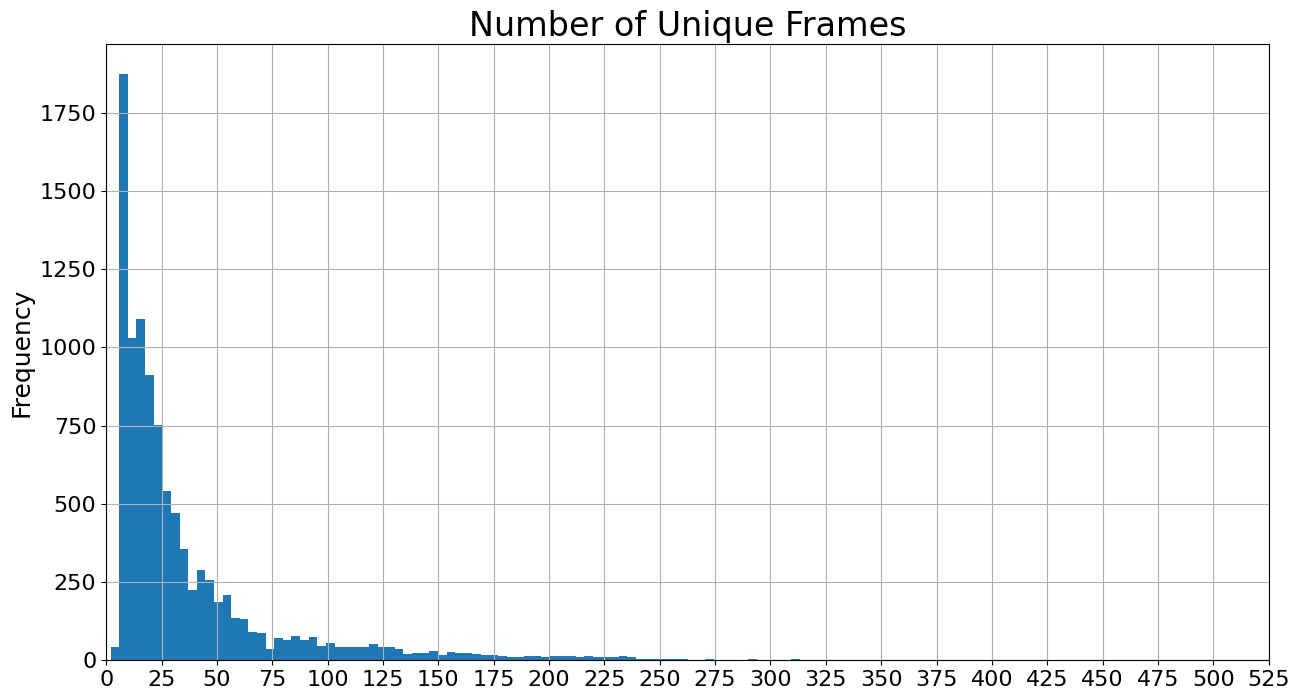

In [11]:
# Number of unique frames in each video
display(pd.Series(N_UNIQUE_FRAMES).describe(percentiles=PERCENTILES).to_frame('N_UNIQUE_FRAMES'))

plt.figure(figsize=(15,8))
plt.title('Number of Unique Frames', size=24)
pd.Series(N_UNIQUE_FRAMES).plot(kind='hist', bins=128)
plt.grid()
xlim = math.ceil(plt.xlim()[1])
plt.xlim(0, xlim)
plt.xticks(np.arange(0, xlim+25, 25))
plt.show() 

,N_MISSING_FRAMES
count,10000.000000
mean,0.004500
std,0.291699
min,0.000000
1%,0.000000
5%,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
95%,0.000000


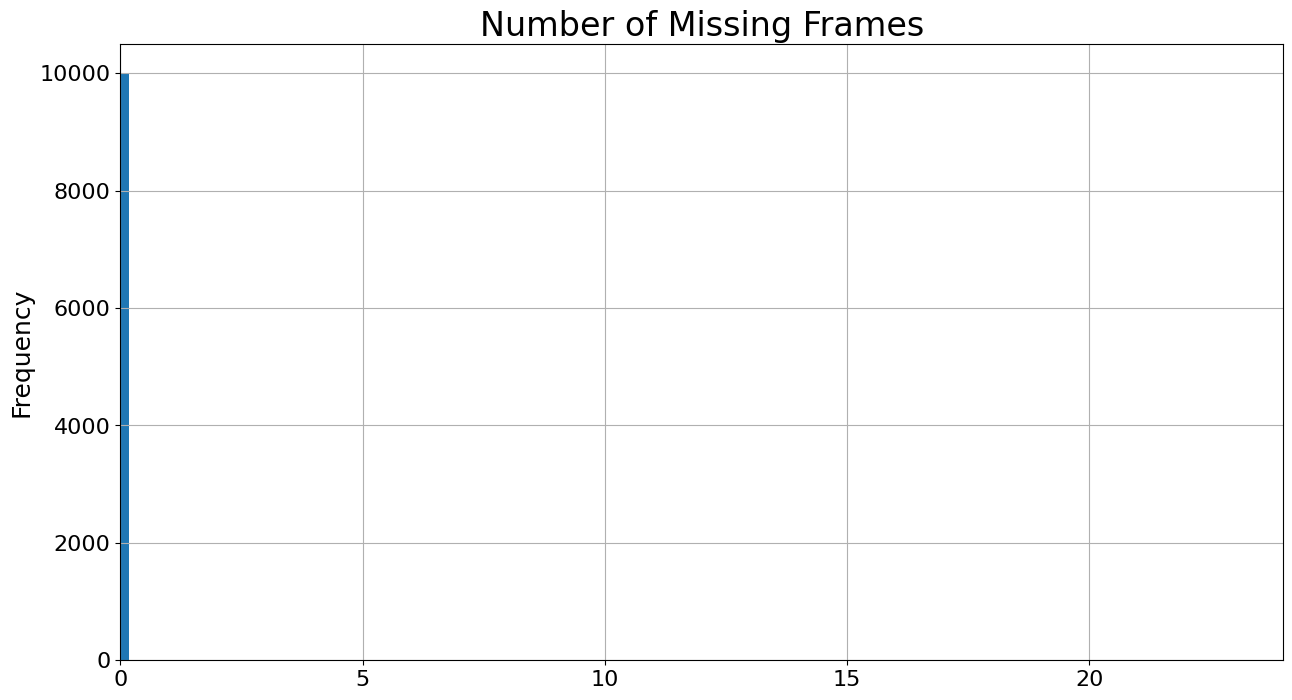

In [12]:
# Number of missing frames, consecutive frames with missing intermediate frame, i.e. 1,2,4,5 but 3 is missing
display(pd.Series(N_MISSING_FRAMES).describe(percentiles=PERCENTILES).to_frame('N_MISSING_FRAMES'))

plt.figure(figsize=(15,8))
plt.title('Number of Missing Frames', size=24)
pd.Series(N_MISSING_FRAMES).plot(kind='hist', bins=128)
plt.grid()
plt.xlim(0, math.ceil(plt.xlim()[1]))
plt.show() 

,MAX_FRAME
count,10000.000000
mean,67.391300
std,59.145194
min,1.000000
1%,12.990000
5%,22.000000
25%,33.000000
50%,42.000000
75%,63.000000
95%,201.000000


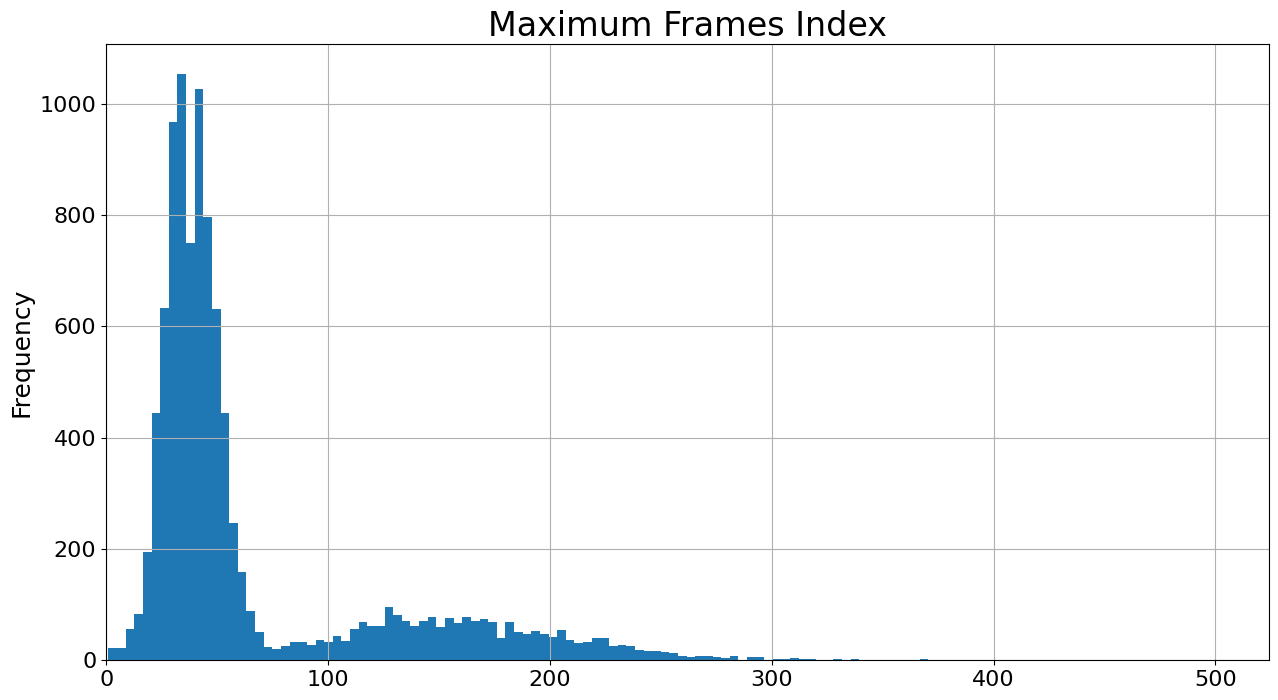

In [13]:
# Maximum frame number
display(pd.Series(MAX_FRAME).describe(percentiles=PERCENTILES).to_frame('MAX_FRAME'))

plt.figure(figsize=(15,8))
plt.title('Maximum Frames Index', size=24)
pd.Series(MAX_FRAME).plot(kind='hist', bins=128)
plt.grid() 
plt.xlim(0, math.ceil(plt.xlim()[1]))
plt.show() 

# Landmark Indices for Lips, Hands, and Pose

In [14]:
USE_TYPES = ['left_hand', 'pose', 'right_hand']
START_IDX = 468
LIPS_IDXS0 = np.array([
        61, 185, 40, 39, 37, 0, 267, 269, 270, 409,
        291, 146, 91, 181, 84, 17, 314, 405, 321, 375,
        78, 191, 80, 81, 82, 13, 312, 311, 310, 415,
        95, 88, 178, 87, 14, 317, 402, 318, 324, 308,
    ])
# Landmark indices in original data
LEFT_HAND_IDXS0 = np.arange(468,489)
RIGHT_HAND_IDXS0 = np.arange(522,543)
LEFT_POSE_IDXS0 = np.array([502, 504, 506, 508, 510])
RIGHT_POSE_IDXS0 = np.array([503, 505, 507, 509, 511])
LANDMARK_IDXS_LEFT_DOMINANT0 = np.concatenate((LIPS_IDXS0, LEFT_HAND_IDXS0, LEFT_POSE_IDXS0))
LANDMARK_IDXS_RIGHT_DOMINANT0 = np.concatenate((LIPS_IDXS0, RIGHT_HAND_IDXS0, RIGHT_POSE_IDXS0))
HAND_IDXS0 = np.concatenate((LEFT_HAND_IDXS0, RIGHT_HAND_IDXS0), axis=0)
N_COLS = LANDMARK_IDXS_LEFT_DOMINANT0.size
# Landmark indices in processed data
LIPS_IDXS = np.argwhere(np.isin(LANDMARK_IDXS_LEFT_DOMINANT0, LIPS_IDXS0)).squeeze()
LEFT_HAND_IDXS = np.argwhere(np.isin(LANDMARK_IDXS_LEFT_DOMINANT0, LEFT_HAND_IDXS0)).squeeze()
RIGHT_HAND_IDXS = np.argwhere(np.isin(LANDMARK_IDXS_LEFT_DOMINANT0, RIGHT_HAND_IDXS0)).squeeze()
HAND_IDXS = np.argwhere(np.isin(LANDMARK_IDXS_LEFT_DOMINANT0, HAND_IDXS0)).squeeze()
POSE_IDXS = np.argwhere(np.isin(LANDMARK_IDXS_LEFT_DOMINANT0, LEFT_POSE_IDXS0)).squeeze()

print(f'# HAND_IDXS: {len(HAND_IDXS)}, N_COLS: {N_COLS}')

# HAND_IDXS: 21, N_COLS: 66


In [15]:
LIPS_START = 0
LEFT_HAND_START = LIPS_IDXS.size
RIGHT_HAND_START = LEFT_HAND_START + LEFT_HAND_IDXS.size
POSE_START = RIGHT_HAND_START + RIGHT_HAND_IDXS.size

print(f'LIPS_START: {LIPS_START}, LEFT_HAND_START: {LEFT_HAND_START}, RIGHT_HAND_START: {RIGHT_HAND_START}, POSE_START: {POSE_START}') 

LIPS_START: 0, LEFT_HAND_START: 40, RIGHT_HAND_START: 61, POSE_START: 61


# Process data Tensorflow

In [16]:
ROWS_PER_FRAME = 543  # number of landmarks per frame

def load_relevant_data_subset(pq_path):
    data_columns = ['x', 'y', 'z']
    data = pd.read_parquet(pq_path, columns=data_columns)
    n_frames = int(len(data) / ROWS_PER_FRAME)
    data = data.values.reshape(n_frames, ROWS_PER_FRAME, len(data_columns))
    return data.astype(np.float32) 

In [17]:
class PreprocessLayer(tf.keras.layers.Layer):
    def __init__(self):
        super(PreprocessLayer, self).__init__()
        normalisation_correction = tf.constant([
                    # Add 0.50 to left hand (original right hand) and substract 0.50 of right hand (original left hand)
                    [0] * len(LIPS_IDXS) + [0.50] * len(LEFT_HAND_IDXS) + [0.50] * len(POSE_IDXS),
                    # Y coordinates stay intact
                    [0] * len(LANDMARK_IDXS_LEFT_DOMINANT0),
                    # Z coordinates stay intact
                    [0] * len(LANDMARK_IDXS_LEFT_DOMINANT0),
                ],
                dtype=tf.float32,
            )
        self.normalisation_correction = tf.transpose(normalisation_correction, [1,0])
        
    def pad_edge(self, t, repeats, side):
        if side == 'LEFT':
            return tf.concat((tf.repeat(t[:1], repeats=repeats, axis=0), t), axis=0)
        elif side == 'RIGHT':
            return tf.concat((t, tf.repeat(t[-1:], repeats=repeats, axis=0)), axis=0)
    
    @tf.function(
        input_signature=(tf.TensorSpec(shape=[None,N_ROWS,N_DIMS], dtype=tf.float32),),
    )
    def call(self, data0):
        # Number of Frames in Video
        N_FRAMES0 = tf.shape(data0)[0]
        
        # Find dominant hand by comparing summed absolute coordinates
        left_hand_sum = tf.math.reduce_sum(tf.where(tf.math.is_nan(tf.gather(data0, LEFT_HAND_IDXS0, axis=1)), 0, 1))
        right_hand_sum = tf.math.reduce_sum(tf.where(tf.math.is_nan(tf.gather(data0, RIGHT_HAND_IDXS0, axis=1)), 0, 1))
        left_dominant = left_hand_sum >= right_hand_sum
        
        # Count non-NaN Hand values in each frame for the dominant hand
        if left_dominant:
            frames_hands_non_nan_sum = tf.math.reduce_sum(
                    tf.where(tf.math.is_nan(tf.gather(data0, LEFT_HAND_IDXS0, axis=1)), 0, 1),
                    axis=[1, 2],
                )
        else:
            frames_hands_non_nan_sum = tf.math.reduce_sum(
                    tf.where(tf.math.is_nan(tf.gather(data0, RIGHT_HAND_IDXS0, axis=1)), 0, 1),
                    axis=[1, 2],
                )
        
        # Find frames indices with coordinates of the dominant hand
        non_empty_frames_idxs = tf.where(frames_hands_non_nan_sum > 0)
        non_empty_frames_idxs = tf.squeeze(non_empty_frames_idxs, axis=1)
        # Filter frames
        data = tf.gather(data0, non_empty_frames_idxs, axis=0)
        
        # Cast Indices in float32 to be compatible with Tensorflow Lite
        non_empty_frames_idxs = tf.cast(non_empty_frames_idxs, tf.float32)
        # Normalize to start with 0
        non_empty_frames_idxs -= tf.reduce_min(non_empty_frames_idxs)
        
        # Number of Frames in Filtered Video
        N_FRAMES = tf.shape(data)[0]
        
        # Gather Relevant Landmark Columns
        if left_dominant:
            data = tf.gather(data, LANDMARK_IDXS_LEFT_DOMINANT0, axis=1)
        else:
            data = tf.gather(data, LANDMARK_IDXS_RIGHT_DOMINANT0, axis=1)
            data = (
                    self.normalisation_correction + (
                        (data - self.normalisation_correction) * tf.where(self.normalisation_correction != 0, -1.0, 1.0))
                )
        
        # Video fits in INPUT_SIZE
        if N_FRAMES < INPUT_SIZE:
            # Pad With -1 to indicate padding
            non_empty_frames_idxs = tf.pad(non_empty_frames_idxs, [[0, INPUT_SIZE-N_FRAMES]], constant_values=-1)
            # Pad Data With Zeros
            data = tf.pad(data, [[0, INPUT_SIZE-N_FRAMES], [0,0], [0,0]], constant_values=0)
            # Fill NaN Values With 0
            data = tf.where(tf.math.is_nan(data), 0.0, data)
            return data, non_empty_frames_idxs
        # Video needs to be downsampled to INPUT_SIZE
        else:
            # Repeat
            if N_FRAMES < INPUT_SIZE**2:
                repeats = tf.math.floordiv(INPUT_SIZE * INPUT_SIZE, N_FRAMES0)
                data = tf.repeat(data, repeats=repeats, axis=0)
                non_empty_frames_idxs = tf.repeat(non_empty_frames_idxs, repeats=repeats, axis=0)

            # Pad To Multiple Of Input Size
            pool_size = tf.math.floordiv(len(data), INPUT_SIZE)
            if tf.math.mod(len(data), INPUT_SIZE) > 0:
                pool_size += 1

            if pool_size == 1:
                pad_size = (pool_size * INPUT_SIZE) - len(data)
            else:
                pad_size = (pool_size * INPUT_SIZE) % len(data)

            # Pad Start/End with Start/End value
            pad_left = tf.math.floordiv(pad_size, 2) + tf.math.floordiv(INPUT_SIZE, 2)
            pad_right = tf.math.floordiv(pad_size, 2) + tf.math.floordiv(INPUT_SIZE, 2)
            if tf.math.mod(pad_size, 2) > 0:
                pad_right += 1

            # Pad By Concatenating Left/Right Edge Values
            data = self.pad_edge(data, pad_left, 'LEFT')
            data = self.pad_edge(data, pad_right, 'RIGHT')

            # Pad Non Empty Frame Indices
            non_empty_frames_idxs = self.pad_edge(non_empty_frames_idxs, pad_left, 'LEFT')
            non_empty_frames_idxs = self.pad_edge(non_empty_frames_idxs, pad_right, 'RIGHT')

            # Reshape to Mean Pool
            data = tf.reshape(data, [INPUT_SIZE, -1, N_COLS, N_DIMS])
            non_empty_frames_idxs = tf.reshape(non_empty_frames_idxs, [INPUT_SIZE, -1])

            # Mean Pool
            data = tf.experimental.numpy.nanmean(data, axis=1)
            non_empty_frames_idxs = tf.experimental.numpy.nanmean(non_empty_frames_idxs, axis=1)

            # Fill NaN Values With 0
            data = tf.where(tf.math.is_nan(data), 0.0, data)
            
            return data, non_empty_frames_idxs
    
preprocess_layer = PreprocessLayer() 

I0000 00:00:1768770839.525233      26 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [18]:
"""
    face: 0:468
    left_hand: 468:489
    pose: 489:522
    right_hand: 522:544
        
"""
def get_data(file_path):
    # Load Raw Data
    data = load_relevant_data_subset(file_path)
    # Process Data Using Tensorflow
    data = preprocess_layer(data)
    
    return data 

In [19]:
def preprocess_data():
    print('Preprocessing Data with 3-Way Split (Train/Val/Test)...')
    
    # First Split: 90% Train, 10% Temp
    from sklearn.model_selection import GroupShuffleSplit
    splitter_1 = GroupShuffleSplit(test_size=0.10, n_splits=2, random_state=SEED)
    PARTICIPANT_IDS = train['participant_id'].values
    train_idxs, temp_idxs = next(splitter_1.split(train, train['sign'], groups=PARTICIPANT_IDS))
    
    train_df = train.iloc[train_idxs].reset_index(drop=True)
    temp_df = train.iloc[temp_idxs].reset_index(drop=True)
    
    # Second Split: Split Temp 50/50 into Val/Test (resulting in 5% Val, 5% Test of total)
    splitter_2 = GroupShuffleSplit(test_size=0.50, n_splits=2, random_state=SEED)
    TEMP_PARTICIPANT_IDS = temp_df['participant_id'].values
    val_idxs, test_idxs = next(splitter_2.split(temp_df, temp_df['sign'], groups=TEMP_PARTICIPANT_IDS))
    
    val_df = temp_df.iloc[val_idxs].reset_index(drop=True)
    test_df = temp_df.iloc[test_idxs].reset_index(drop=True)
    
    print(f'Train Samples: {len(train_df)}, Val Samples: {len(val_df)}, Test Samples: {len(test_df)}')
    
    # Determine Shape from First Sample
    print('Determining data shape...')
    first_path = train_df.iloc[0]['file_path']
    first_data, first_non_empty = get_data(first_path)
    first_data = first_data.numpy() if hasattr(first_data, 'numpy') else np.array(first_data)
    row_dim = INPUT_SIZE
    col_dim = first_data.shape[1]
    dim_dim = N_DIMS
    
    print(f'Target Shape: (N, {row_dim}, {col_dim}, {dim_dim})')
    
    # Create Memmaps
    import os
    from numpy.lib.format import open_memmap
    
    # Define helper to create memmaps
    def create_mmap(name, shape, dtype):
        if os.path.exists(name): os.remove(name)
        return open_memmap(name, mode='w+', dtype=dtype, shape=shape)
    
    X_train = create_mmap('X_train.npy', (len(train_df), row_dim, col_dim, dim_dim), np.float32)
    y_train = create_mmap('y_train.npy', (len(train_df),), np.int32)
    ne_train = create_mmap('NON_EMPTY_FRAME_IDXS_TRAIN.npy', (len(train_df), row_dim), np.float32)
    
    X_val = create_mmap('X_val.npy', (len(val_df), row_dim, col_dim, dim_dim), np.float32)
    y_val = create_mmap('y_val.npy', (len(val_df),), np.int32)
    ne_val = create_mmap('NON_EMPTY_FRAME_IDXS_VAL.npy', (len(val_df), row_dim), np.float32)
    
    X_test = create_mmap('X_test.npy', (len(test_df), row_dim, col_dim, dim_dim), np.float32)
    y_test = create_mmap('y_test.npy', (len(test_df),), np.int32)
    ne_test = create_mmap('NON_EMPTY_FRAME_IDXS_TEST.npy', (len(test_df), row_dim), np.float32)
    
    # Processing Helper
    def process_and_save(df, X_mmap, y_mmap, ne_mmap, desc):
        for i, row in tqdm(df.iterrows(), total=len(df), desc=desc):
            data, non_empty_from_preprocess = get_data(row['file_path'])
            data = data.numpy() if hasattr(data, 'numpy') else np.array(data)
            if len(data) < INPUT_SIZE:
                data = np.pad(data, ((0, INPUT_SIZE - len(data)), (0, 0), (0, 0)), mode='constant', constant_values=0)
                non_empty = np.array([1]*len(data) + [0]*(INPUT_SIZE-len(data)), dtype=np.float32)
            else:
                idxs = np.floor(np.linspace(0, len(data)-1, INPUT_SIZE)).astype(int)
                data = data[idxs]
                non_empty = np.ones(INPUT_SIZE, dtype=np.float32)
            
            if np.isnan(data).sum() > 0:
                data = np.nan_to_num(data)

            X_mmap[i] = data
            y_mmap[i] = row['sign_ord']
            ne_mmap[i] = non_empty
            
            if i % 1000 == 0: X_mmap.flush()
        X_mmap.flush(); y_mmap.flush(); ne_mmap.flush()
    
    # Run Processing
    process_and_save(train_df, X_train, y_train, ne_train, 'Processing Train')
    process_and_save(val_df, X_val, y_val, ne_val, 'Processing Val')
    process_and_save(test_df, X_test, y_test, ne_test, 'Processing Test')
    
    print('Preprocessing Complete. Data saved to disk.')

In [20]:
# Preprocess All Data From Scratch
if PREPROCESS_DATA:
    preprocess_data()
    ROOT_DIR = '.'
else:
    ROOT_DIR = '/kaggle/input/gislr-dataset-public'
    
# Load Data
if USE_VAL:
    # Load Train
    X_train = np.load(f'{ROOT_DIR}/X_train.npy', mmap_mode='r')
    y_train = np.load(f'{ROOT_DIR}/y_train.npy', mmap_mode='r')
    NON_EMPTY_FRAME_IDXS_TRAIN = np.load(f'{ROOT_DIR}/NON_EMPTY_FRAME_IDXS_TRAIN.npy', mmap_mode='r')
    # Load Val
    X_val = np.load(f'{ROOT_DIR}/X_val.npy', mmap_mode='r') 
    X_test = np.load(f'{ROOT_DIR}/X_test.npy', mmap_mode='r')
    y_test = np.load(f'{ROOT_DIR}/y_test.npy', mmap_mode='r')
    NON_EMPTY_FRAME_IDXS_TEST = np.load(f'{ROOT_DIR}/NON_EMPTY_FRAME_IDXS_TEST.npy', mmap_mode='r')
    y_val = np.load(f'{ROOT_DIR}/y_val.npy', mmap_mode='r')
    NON_EMPTY_FRAME_IDXS_VAL = np.load(f'{ROOT_DIR}/NON_EMPTY_FRAME_IDXS_VAL.npy', mmap_mode='r')
    # Define validation Data
    y_val_oh = tf.one_hot(y_val, NUM_CLASSES)
    validation_data = ({ 'frames': X_val, 'non_empty_frame_idxs': NON_EMPTY_FRAME_IDXS_VAL }, y_val_oh)
else:
    X_train = np.load(f'{ROOT_DIR}/X.npy', mmap_mode='r')
    y_train = np.load(f'{ROOT_DIR}/y.npy', mmap_mode='r')
    NON_EMPTY_FRAME_IDXS_TRAIN = np.load(f'{ROOT_DIR}/NON_EMPTY_FRAME_IDXS.npy', mmap_mode='r')
    validation_data = None

# Train 
print_shape_dtype([X_train, y_train, NON_EMPTY_FRAME_IDXS_TRAIN], ['X_train', 'y_train', 'NON_EMPTY_FRAME_IDXS_TRAIN'])
# Val
if USE_VAL:
    print_shape_dtype([X_val, y_val, NON_EMPTY_FRAME_IDXS_VAL], ['X_val', 'y_val', 'NON_EMPTY_FRAME_IDXS_VAL'])
# Sanity Check
print(f'# NaN Values X_train: {np.isnan(X_train).sum()}') 

Preprocessing Data with 3-Way Split (Train/Val/Test)...
Train Samples: 80229, Val Samples: 4656, Test Samples: 9592
Determining data shape...
Target Shape: (N, 64, 66, 3)


Processing Train:   0%|          | 0/80229 [00:00<?, ?it/s]

Processing Val:   0%|          | 0/4656 [00:00<?, ?it/s]

Processing Test:   0%|          | 0/9592 [00:00<?, ?it/s]

Preprocessing Complete. Data saved to disk.
X_train shape: (80229, 64, 66, 3), dtype: float32
y_train shape: (80229,), dtype: int32
NON_EMPTY_FRAME_IDXS_TRAIN shape: (80229, 64), dtype: float32
X_val shape: (4656, 64, 66, 3), dtype: float32
y_val shape: (4656,), dtype: int32
NON_EMPTY_FRAME_IDXS_VAL shape: (4656, 64), dtype: float32
# NaN Values X_train: 0


In [21]:
# Class Count
display(pd.Series(y_train).value_counts().to_frame('Class Count').iloc[[0,1,2,3,4, -5,-4,-3,-2,-1]]) 

,Class Count
135,358
136,352
60,351
194,351
67,348
170,277
249,267
56,266
21,263
231,255


# Number of Frames

  0%|          | 0/64 [00:00<?, ?it/s]

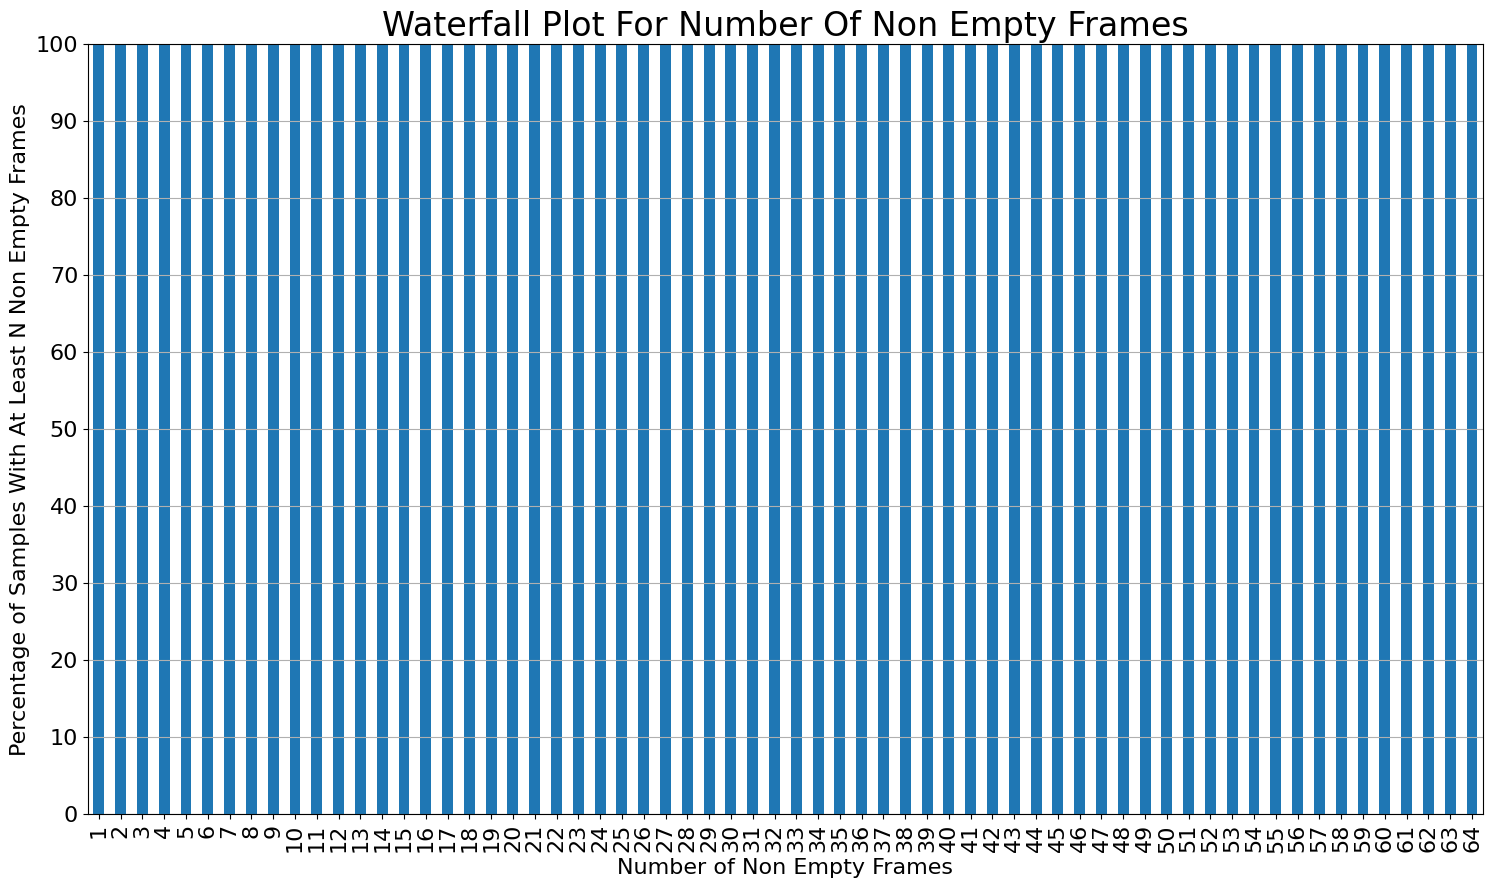

In [22]:
# Vast majority of samples fits has less than 32 non empty frames
N_EMPTY_FRAMES = (NON_EMPTY_FRAME_IDXS_TRAIN != -1).sum(axis=1) 
N_EMPTY_FRAMES_WATERFALL = []
for n in tqdm(range(1,INPUT_SIZE+1)):
    N_EMPTY_FRAMES_WATERFALL.append(sum(N_EMPTY_FRAMES >= n) / len(NON_EMPTY_FRAME_IDXS_TRAIN) * 100)

plt.figure(figsize=(18,10))
plt.title('Waterfall Plot For Number Of Non Empty Frames')
pd.Series(N_EMPTY_FRAMES_WATERFALL).plot(kind='bar')
plt.grid(axis='y')
plt.xticks(np.arange(INPUT_SIZE), np.arange(1, INPUT_SIZE+1))
plt.xlabel('Number of Non Empty Frames', size=16)
plt.yticks(np.arange(0, 100+10, 10))
plt.ylim(0, 100)
plt.ylabel('Percentage of Samples With At Least N Non Empty Frames', size=16)
plt.show() 

# Percentage of Frames Filled

In [23]:
# Percentage of frames filled, this is the maximum fill percentage of each landmark
P_DATA_FILLED = (NON_EMPTY_FRAME_IDXS_TRAIN != -1).sum() / NON_EMPTY_FRAME_IDXS_TRAIN.size * 100
print(f'P_DATA_FILLED: {P_DATA_FILLED:.2f}%') 

P_DATA_FILLED: 100.00%


# Feature Stats - Lips

In [24]:
# Percentage of Lips Measurements
P_LEFT_LIPS_MEASUREMENTS = (X_train[:,:,LIPS_IDXS] != 0).sum() / X_train[:,:,LIPS_IDXS].size / P_DATA_FILLED * 1e4
print(f'P_LEFT_LIPS_MEASUREMENTS: {P_LEFT_LIPS_MEASUREMENTS:.2f}%') 

P_LEFT_LIPS_MEASUREMENTS: 33.37%


  0%|          | 0/40 [00:00<?, ?it/s]

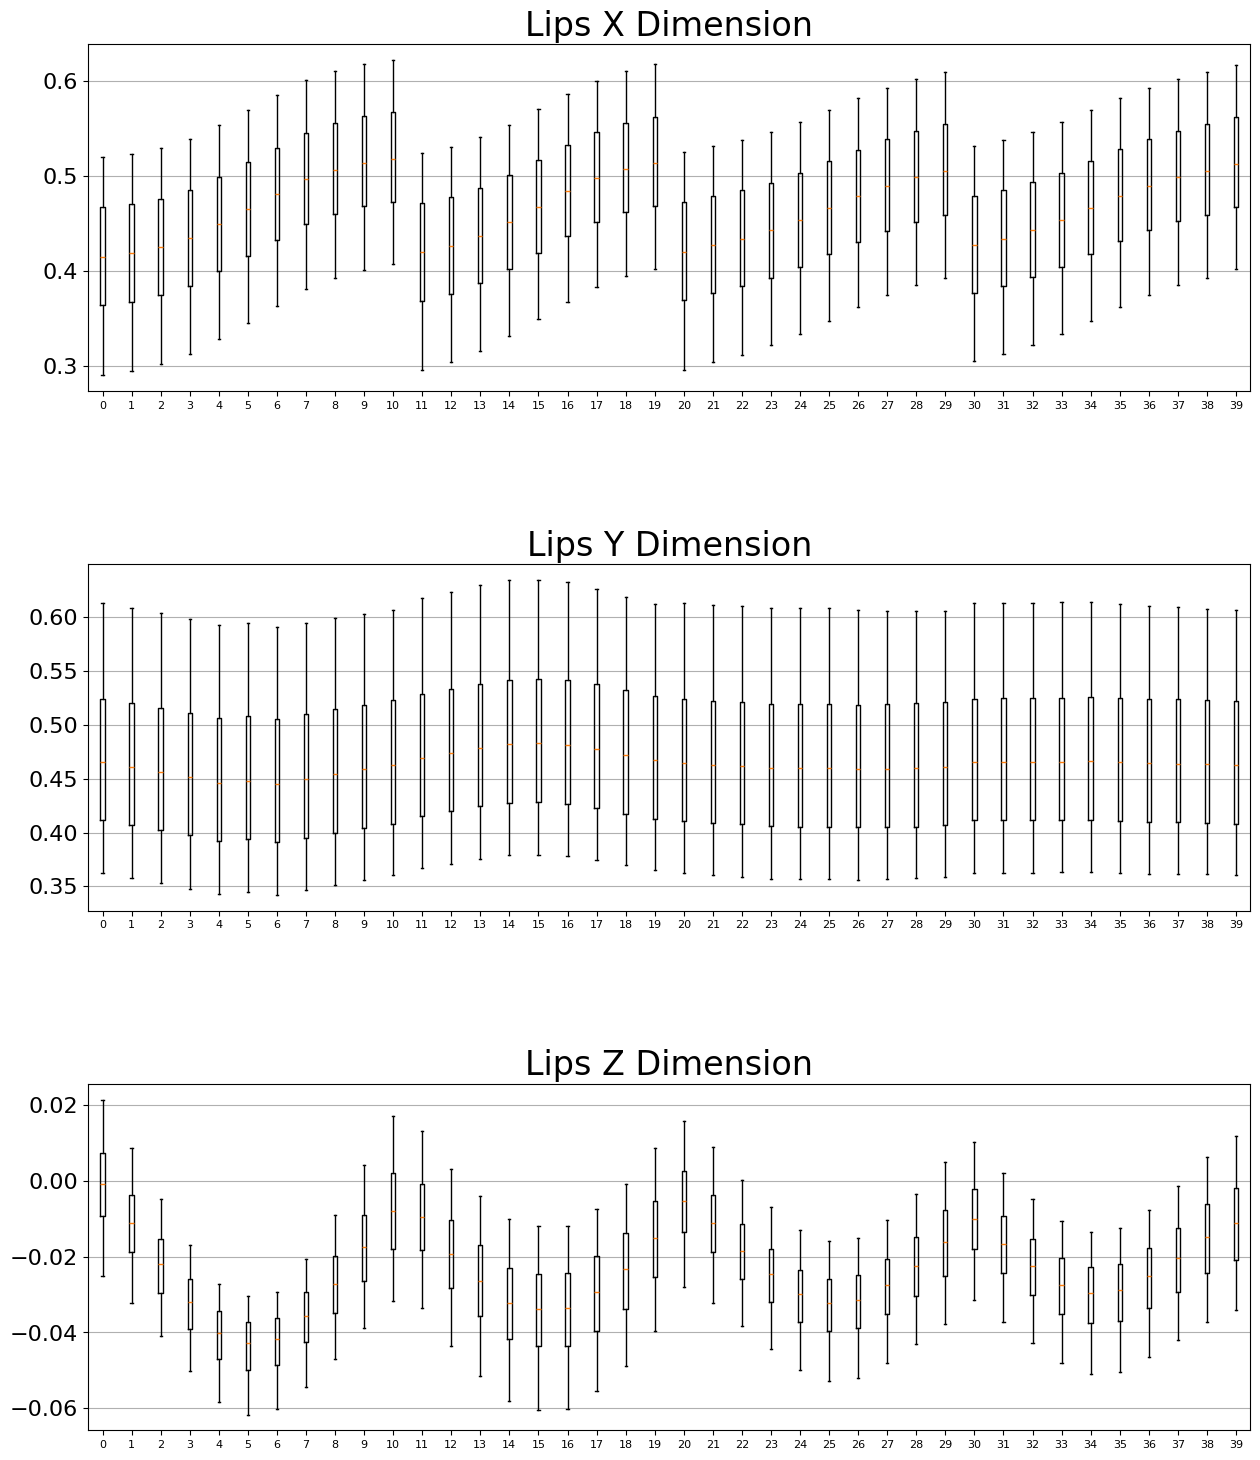

In [25]:
def get_lips_median_iqr():
    # LIPS
    LIPS_MEDIAN_X = np.zeros([LIPS_IDXS.size], dtype=np.float32)
    LIPS_MEDIAN_Y = np.zeros([LIPS_IDXS.size], dtype=np.float32)
    LIPS_IQR_X = np.zeros([LIPS_IDXS.size], dtype=np.float32)
    LIPS_IQR_Y = np.zeros([LIPS_IDXS.size], dtype=np.float32)

    fig, axes = plt.subplots(3, 1, figsize=(15, N_DIMS*6))

    for col, ll in enumerate(tqdm( np.transpose(X_train[:,:,LIPS_IDXS], [2,3,0,1]).reshape([LIPS_IDXS.size, N_DIMS, -1]) )):
        for dim, l in enumerate(ll):
            v = l[np.nonzero(l)]
            if dim == 0: # X
                LIPS_MEDIAN_X[col] = np.median(v)
                LIPS_IQR_X[col] = iqr(v)
            if dim == 1: # Y
                LIPS_MEDIAN_Y[col] = np.median(v)
                LIPS_IQR_Y[col] = iqr(v)

            axes[dim].boxplot(v, notch=False, showfliers=False, positions=[col], whis=[5,95])

    for ax, dim_name in zip(axes, DIM_NAMES):
        ax.set_title(f'Lips {dim_name.upper()} Dimension', size=24)
        ax.tick_params(axis='x', labelsize=8)
        ax.grid(axis='y')

    plt.subplots_adjust(hspace=0.50)
    plt.show()

    LIPS_MEDIAN = np.array([LIPS_MEDIAN_X, LIPS_MEDIAN_Y]).T
    LIPS_IQR = np.array([LIPS_IQR_X, LIPS_IQR_Y]).T
    
    return LIPS_MEDIAN, LIPS_IQR

LIPS_MEDIAN, LIPS_IQR = get_lips_median_iqr() 

# Feature Stats - Hands

In [26]:
# Verify Normalised to Left Hand Dominant
P_LEFT_HAND_MEASUREMENTS = (X_train[:,:,LEFT_HAND_IDXS] != 0).sum() / X_train[:,:,LEFT_HAND_IDXS].size / P_DATA_FILLED * 1e4
# P_RIGHT_HAND_MEASUREMENTS = (X_train[:,:,RIGHT_HAND_IDXS] != 0).sum() / X_train[:,:,RIGHT_HAND_IDXS].size / P_DATA_FILLED * 1e4
print(f'P_LEFT_HAND_MEASUREMENTS: {P_LEFT_HAND_MEASUREMENTS:.2f}%') 

P_LEFT_HAND_MEASUREMENTS: 33.59%


  0%|          | 0/21 [00:00<?, ?it/s]

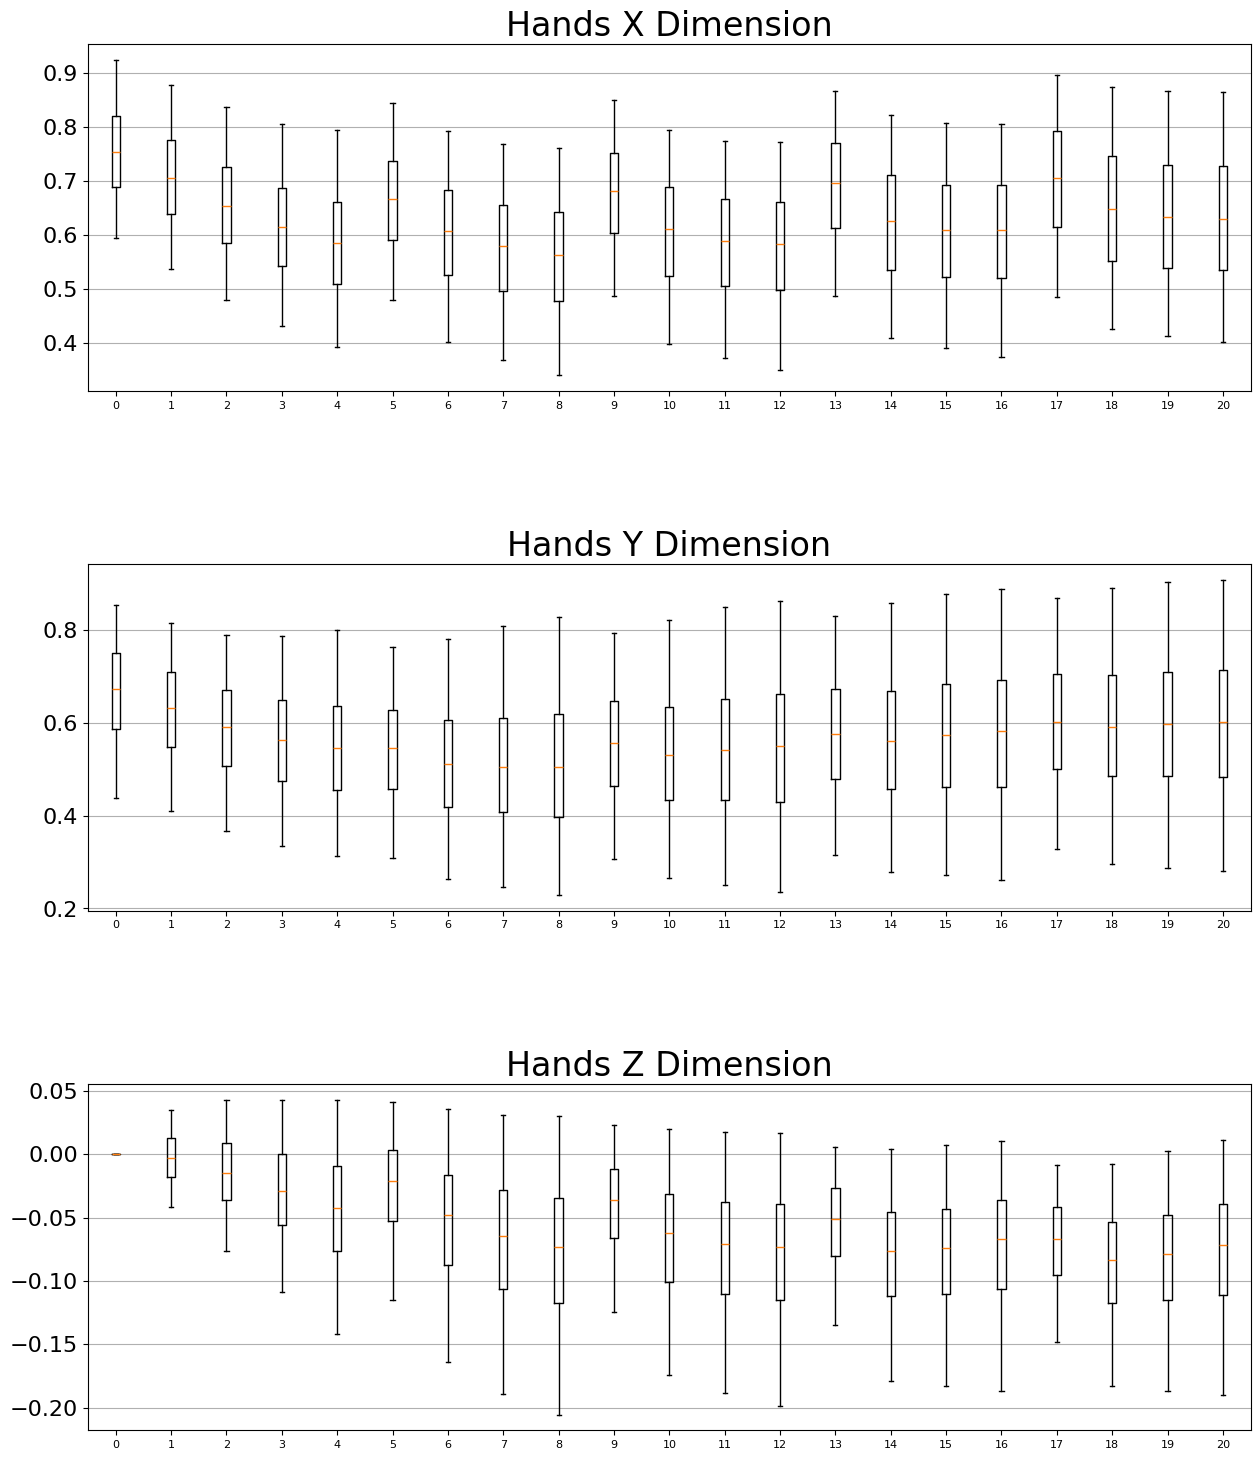

In [27]:
def get_left_right_hand_median_iqr():
    # LEFT HAND
    LEFT_HANDS_MEDIAN_X = np.zeros([LEFT_HAND_IDXS.size], dtype=np.float32)
    LEFT_HANDS_MEDIAN_Y = np.zeros([LEFT_HAND_IDXS.size], dtype=np.float32)
    LEFT_HANDS_IQR_X = np.zeros([LEFT_HAND_IDXS.size], dtype=np.float32)
    LEFT_HANDS_IQR_Y = np.zeros([LEFT_HAND_IDXS.size], dtype=np.float32)

    fig, axes = plt.subplots(3, 1, figsize=(15, N_DIMS*6))

    for col, ll in enumerate(tqdm( np.transpose(X_train[:,:,LEFT_HAND_IDXS], [2,3,0,1]).reshape([LEFT_HAND_IDXS.size, N_DIMS, -1]) )):
        for dim, l in enumerate(ll):
            v = l[np.nonzero(l)]
            if dim == 0: # X
                LEFT_HANDS_MEDIAN_X[col] = np.median(v)
                LEFT_HANDS_IQR_X[col] = iqr(v)
            if dim == 1: # Y
                LEFT_HANDS_MEDIAN_Y[col] = np.median(v)
                LEFT_HANDS_IQR_Y[col] = iqr(v)
            # Plot
            axes[dim].boxplot(v, notch=False, showfliers=False, positions=[col], whis=[5,95])

    for ax, dim_name in zip(axes, DIM_NAMES):
        ax.set_title(f'Hands {dim_name.upper()} Dimension', size=24)
        ax.tick_params(axis='x', labelsize=8)
        ax.grid(axis='y')

    plt.subplots_adjust(hspace=0.50)
    plt.show()

    LEFT_HANDS_MEDIAN = np.array([LEFT_HANDS_MEDIAN_X, LEFT_HANDS_MEDIAN_Y]).T
    LEFT_HANDS_IQR = np.array([LEFT_HANDS_IQR_X, LEFT_HANDS_IQR_Y]).T
    
    return LEFT_HANDS_MEDIAN, LEFT_HANDS_IQR

LEFT_HANDS_MEDIAN, LEFT_HANDS_IQR = get_left_right_hand_median_iqr() 

# Feature Stats - Pose

In [28]:
# Percentage of Lips Measurements
P_POSE_MEASUREMENTS = (X_train[:,:,POSE_IDXS] != 0).sum() / X_train[:,:,POSE_IDXS].size / P_DATA_FILLED * 1e4
print(f'P_POSE_MEASUREMENTS: {P_POSE_MEASUREMENTS:.2f}%') 

P_POSE_MEASUREMENTS: 33.59%


  0%|          | 0/5 [00:00<?, ?it/s]

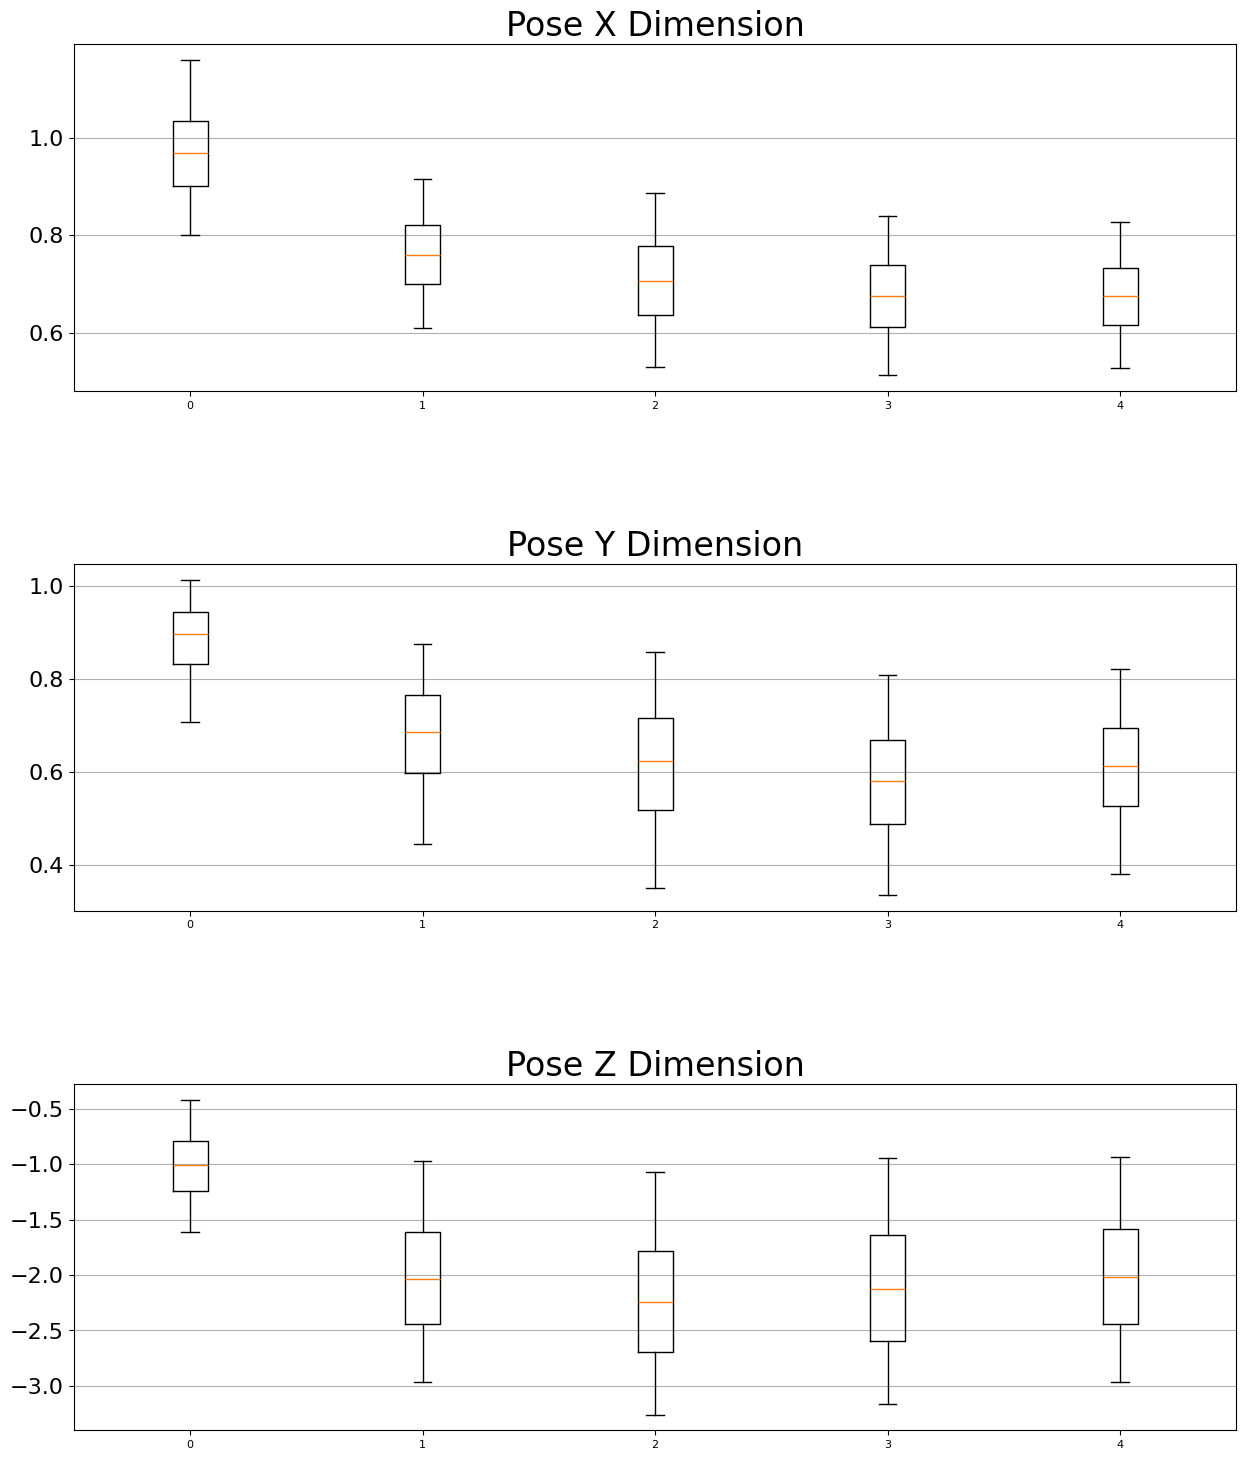

In [29]:
def get_pose_median_iqr():
    # POSE
    POSE_MEDIAN_X = np.zeros([POSE_IDXS.size], dtype=np.float32)
    POSE_MEDIAN_Y = np.zeros([POSE_IDXS.size], dtype=np.float32)
    POSE_IQR_X = np.zeros([POSE_IDXS.size], dtype=np.float32)
    POSE_IQR_Y = np.zeros([POSE_IDXS.size], dtype=np.float32)

    fig, axes = plt.subplots(3, 1, figsize=(15, N_DIMS*6))

    for col, ll in enumerate(tqdm( np.transpose(X_train[:,:,POSE_IDXS], [2,3,0,1]).reshape([POSE_IDXS.size, N_DIMS, -1]) )):
        for dim, l in enumerate(ll):
            v = l[np.nonzero(l)]
            if dim == 0: # X
                POSE_MEDIAN_X[col] = np.median(v)
                POSE_IQR_X[col] = iqr(v)
            if dim == 1: # Y
                POSE_MEDIAN_Y[col] = np.median(v)
                POSE_IQR_Y[col] = iqr(v)

            axes[dim].boxplot(v, notch=False, showfliers=False, positions=[col], whis=[5,95])

    for ax, dim_name in zip(axes, DIM_NAMES):
        ax.set_title(f'Pose {dim_name.upper()} Dimension', size=24)
        ax.tick_params(axis='x', labelsize=8)
        ax.grid(axis='y')

    plt.subplots_adjust(hspace=0.50)
    plt.show()

    POSE_MEDIAN = np.array([POSE_MEDIAN_X, POSE_MEDIAN_Y]).T
    POSE_IQR = np.array([POSE_IQR_X, POSE_IQR_Y]).T
    
    return POSE_MEDIAN, POSE_IQR

POSE_MEDIAN, POSE_IQR = get_pose_median_iqr() 

# Samples

In [30]:
# Custom sampler to get a batch containing N times all signs
def get_train_batch_all_signs(X, y, NON_EMPTY_FRAME_IDXS, n=BATCH_ALL_SIGNS_N, mixup_alpha=0.4):
    # Dictionary mapping ordinally encoded sign to corresponding sample indices
    CLASS2IDXS = {}
    for i in range(NUM_CLASSES):
        CLASS2IDXS[i] = np.argwhere(y == i).squeeze().astype(np.int32)
            
    while True:
        # Arrays to store batch
        X_batch = np.zeros([NUM_CLASSES*n, INPUT_SIZE, N_COLS, N_DIMS], dtype=np.float32)
        y_batch = np.zeros([NUM_CLASSES*n, NUM_CLASSES], dtype=np.float32)
        non_empty_frame_idxs_batch = np.zeros([NUM_CLASSES*n, INPUT_SIZE], dtype=np.float32)

        # Fill batch arrays
        for i in range(NUM_CLASSES):
            idxs = np.random.choice(CLASS2IDXS[i], n)
            X_batch[i*n:(i+1)*n] = X[idxs]
            non_empty_frame_idxs_batch[i*n:(i+1)*n] = NON_EMPTY_FRAME_IDXS[idxs]
            y_batch[i*n:(i+1)*n, i] = 1.0
        
        # Add augmentation (reduced aggressiveness)
        for b in range(X_batch.shape[0]):
            # Geometric Augmentation
            def augment_points(points):
                if len(points) == 0:
                    return points
                centroid = np.mean(points, axis=0)
                points_centered = points - centroid
                angle = np.random.uniform(-15, 15) * np.pi / 180
                rot_matrix = np.array([[np.cos(angle), -np.sin(angle)], 
                                       [np.sin(angle), np.cos(angle)]])
                points_rot = points_centered @ rot_matrix.T
                scale = np.random.uniform(0.9, 1.1)  # Reduced from 0.85-1.15
                points_scaled = points_rot * scale
                trans = np.random.uniform(-0.05, 0.05, 2)  # Reduced from -0.1 to 0.1
                points_trans = points_scaled + trans
                points_aug = points_trans + centroid
                points_aug += np.random.normal(0, 0.01, points_aug.shape)  # Reduced noise
                return points_aug
            
            # Process each landmark group
            for start_idx, num_points, group_idxs in [
                (LIPS_START, LIPS_IDXS.size, LIPS_IDXS),
                (LEFT_HAND_START, LEFT_HAND_IDXS.size, LEFT_HAND_IDXS),
                (POSE_START, POSE_IDXS.size, POSE_IDXS)
            ]:
                group_xy = X_batch[b, :, group_idxs, :2]
                mask = np.any(group_xy != 0, axis=-1)
                if np.any(mask):
                    frame_idxs, point_idxs = np.where(mask)
                    non_zero_coords = group_xy[frame_idxs, point_idxs, :]
                    augmented_coords = augment_points(non_zero_coords)
                    group_xy[frame_idxs, point_idxs, :] = augmented_coords
                X_batch[b, :, group_idxs, :2] = group_xy
            
            # Feature Masking - REDUCED from 30% to 15%
            if np.random.rand() < 0.15:
                drop_mask = np.random.rand(N_COLS) < np.random.uniform(0.05, 0.15)
                X_batch[b, :, drop_mask, :] = 0

            # Time Masking - REDUCED from 50% to 30%
            if np.random.rand() < 0.3:
                len_mask = np.random.randint(2, 8)  # Reduced from 2-12
                start_mask = np.random.randint(0, INPUT_SIZE - len_mask)
                X_batch[b, start_mask:start_mask+len_mask, :, :] = 0
                non_empty_frame_idxs_batch[b, start_mask:start_mask+len_mask] = -1

        # MixUp - REDUCED from 70% to 30%
        if mixup_alpha > 0 and np.random.rand() < 0.3:
            lam = np.random.beta(mixup_alpha, mixup_alpha)
            perm_indices = np.random.permutation(X_batch.shape[0])
            
            X_batch = lam * X_batch + (1 - lam) * X_batch[perm_indices]
            y_batch = lam * y_batch + (1 - lam) * y_batch[perm_indices]
            
            if lam < 0.5:
                non_empty_frame_idxs_batch = non_empty_frame_idxs_batch[perm_indices]
        
        yield { 'frames': X_batch, 'non_empty_frame_idxs': non_empty_frame_idxs_batch }, y_batch

In [31]:
dummy_dataset = get_train_batch_all_signs(X_train, y_train, NON_EMPTY_FRAME_IDXS_TRAIN)
X_batch, y_batch = next(dummy_dataset)

for k, v in X_batch.items():
    print(f'{k} shape: {v.shape}, dtype: {v.dtype}')

# Batch shape/dtype
print(f'y_batch shape: {y_batch.shape}, dtype: {y_batch.dtype}')
# Verify each batch contains each sign exactly N times
display(pd.Series(np.argmax(y_batch, axis=1)).value_counts().to_frame('Counts')) 

frames shape: (1000, 64, 66, 3), dtype: float32
non_empty_frame_idxs shape: (1000, 64), dtype: float32
y_batch shape: (1000, 250), dtype: float32


,Counts
0,4
1,4
2,4
3,4
4,4
...,...
245,4
246,4
247,4
248,4


# Model Config

In [32]:
# Epsilon value for layer normalisation
LAYER_NORM_EPS = 1e-6

# Dense layer units for landmarks
LIPS_UNITS = 192 # 384 or 128
HANDS_UNITS = 192 # 384
POSE_UNITS = 192 # 384
# final embedding and transformer embedding size
UNITS = 320 # 512 or 256

# Transformer
NUM_BLOCKS = 2
MLP_RATIO = 2

# Dropout
EMBEDDING_DROPOUT = 0.20 #0.00
MLP_DROPOUT_RATIO = 0.40 #0.30
CLASSIFIER_DROPOUT_RATIO = 0.50 #0.10

# Initiailizers
INIT_HE_UNIFORM = tf.keras.initializers.he_uniform
INIT_GLOROT_UNIFORM = tf.keras.initializers.glorot_uniform
INIT_ZEROS = tf.keras.initializers.constant(0.0)
# Activations
GELU = tf.keras.activations.gelu

In [33]:
def scaled_dot_product(q,k,v, softmax, attention_mask):
    #calculates Q . K(transpose)
    qkt = tf.matmul(q,k,transpose_b=True)
    # calculates scaling factor
    dk = tf.math.sqrt(tf.cast(q.shape[-1],dtype=tf.float32))
    scaled_qkt = qkt/dk
    softmax = softmax(scaled_qkt, mask=attention_mask)
    
    z = tf.matmul(softmax,v)
    #shape: (m,Tx,depth), same shape as q,k,v
    return z

class MultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self,d_model,num_of_heads):
        super(MultiHeadAttention,self).__init__()
        self.d_model = d_model
        self.num_of_heads = num_of_heads
        self.depth = d_model//num_of_heads
        self.wq = [tf.keras.layers.Dense(self.depth) for i in range(num_of_heads)]
        self.wk = [tf.keras.layers.Dense(self.depth) for i in range(num_of_heads)]
        self.wv = [tf.keras.layers.Dense(self.depth) for i in range(num_of_heads)]
        self.wo = tf.keras.layers.Dense(d_model)
        self.softmax = tf.keras.layers.Softmax()
        
    def call(self,x, attention_mask):
        
        multi_attn = []
        for i in range(self.num_of_heads):
            Q = self.wq[i](x)
            K = self.wk[i](x)
            V = self.wv[i](x)
            multi_attn.append(scaled_dot_product(Q,K,V, self.softmax, attention_mask))
            
        multi_head = tf.concat(multi_attn,axis=-1)
        multi_head_attention = self.wo(multi_head)
        return multi_head_attention 

In [34]:
# Full Transformer
class Transformer(tf.keras.Model):
    def __init__(self, num_blocks):
        super(Transformer, self).__init__(name='transformer')
        self.num_blocks = num_blocks
    
    def build(self, input_shape):
        self.ln_1s = []
        self.mhas = []
        self.ln_2s = []
        self.mlps = []
        # Make Transformer Blocks
        for i in range(self.num_blocks):
            # Multi-Head Attention
            self.mhas.append(MultiHeadAttention(UNITS, 8))
            # Multi Layer Perception
            self.mlps.append(tf.keras.Sequential([
                tf.keras.layers.Dense(UNITS * MLP_RATIO, activation=GELU, kernel_initializer=INIT_GLOROT_UNIFORM),
                tf.keras.layers.Dropout(MLP_DROPOUT_RATIO),
                tf.keras.layers.Dense(UNITS, kernel_initializer=INIT_HE_UNIFORM),
            ]))
        
    def call(self, x, attention_mask):
        # Iterate input over transformer blocks
        for mha, mlp in zip(self.mhas, self.mlps):
            x = x + mha(x, attention_mask)
            x = x + mlp(x)
    
        return x 

# Landmark Embedding

In [35]:
class LandmarkEmbedding(tf.keras.Model):
    def __init__(self, units, name):
        super(LandmarkEmbedding, self).__init__(name=f'{name}_embedding')
        self.units = units
        
    def build(self, input_shape):
        # Embedding for missing landmark in frame, initialized with zeros
        self.empty_embedding = self.add_weight(
            name=f'{self.name}_empty_embedding',
            shape=[self.units],
            initializer=INIT_ZEROS,
        )
        # Embedding
        self.dense = tf.keras.Sequential([
            tf.keras.layers.Dense(self.units, name=f'{self.name}_dense_1', use_bias=False, kernel_initializer=INIT_GLOROT_UNIFORM),
            tf.keras.layers.Activation(GELU),
            tf.keras.layers.Dense(self.units, name=f'{self.name}_dense_2', use_bias=False, kernel_initializer=INIT_HE_UNIFORM),
        ], name=f'{self.name}_dense')

    def call(self, x):
        return tf.where(
                # Checks whether landmark is missing in frame
                tf.reduce_sum(x, axis=2, keepdims=True) == 0,
                # If so, the empty embedding is used
                self.empty_embedding,
                # Otherwise the landmark data is embedded
                self.dense(x),
            )

In [36]:
class Embedding(tf.keras.Model):
    def __init__(self):
        super(Embedding, self).__init__()
        
    def get_diffs(self, l):
        S = l.shape[2]
        other = tf.expand_dims(l, 3)
        other = tf.repeat(other, S, axis=3)
        other = tf.transpose(other, [0,1,3,2])
        diffs = tf.expand_dims(l, 3) - other
        diffs = tf.reshape(diffs, [-1, INPUT_SIZE, S*S])
        return diffs

    def build(self, input_shape):
        # Positional Embedding, initialized with zeros
        self.positional_embedding = tf.keras.layers.Embedding(INPUT_SIZE+1, UNITS, embeddings_initializer=INIT_ZEROS)
        # Embedding layer for Landmarks
        self.lips_embedding = LandmarkEmbedding(LIPS_UNITS, 'lips')
        self.left_hand_embedding = LandmarkEmbedding(HANDS_UNITS, 'left_hand')
        self.pose_embedding = LandmarkEmbedding(POSE_UNITS, 'pose')
        # Landmark Weights
        self.landmark_weights = tf.Variable(tf.zeros([3], dtype=tf.float32), name='landmark_weights')
        # Fully Connected Layers for combined landmarks
        self.fc = tf.keras.Sequential([
            tf.keras.layers.Dense(UNITS, name='fully_connected_1', use_bias=False, kernel_initializer=INIT_GLOROT_UNIFORM),
            tf.keras.layers.Activation(GELU),
            tf.keras.layers.Dense(UNITS, name='fully_connected_2', use_bias=False, kernel_initializer=INIT_HE_UNIFORM),
        ], name='fc')


    def call(self, lips0, left_hand0, pose0, non_empty_frame_idxs, training=False):
        # Lips
        lips_embedding = self.lips_embedding(lips0)
        # Left Hand
        left_hand_embedding = self.left_hand_embedding(left_hand0)
        # Pose
        pose_embedding = self.pose_embedding(pose0)
        # Merge Embeddings of all landmarks with mean pooling
        x = tf.stack((
            lips_embedding, left_hand_embedding, pose_embedding,
        ), axis=3)
        x = x * tf.nn.softmax(self.landmark_weights)
        x = tf.reduce_sum(x, axis=3)
        # Fully Connected Layers
        x = self.fc(x)
        # Add Positional Embedding
        max_frame_idxs = tf.clip_by_value(
                tf.reduce_max(non_empty_frame_idxs, axis=1, keepdims=True),
                1,
                np.inf, #PINF
            )
        normalised_non_empty_frame_idxs = tf.where(
            tf.math.equal(non_empty_frame_idxs, -1.0),
            INPUT_SIZE,
            tf.cast(
                non_empty_frame_idxs / max_frame_idxs * INPUT_SIZE,
                tf.int32,
            ),
        )
        x = x + self.positional_embedding(normalised_non_empty_frame_idxs)
        
        return x

# Categorical Cross Entropy with label Smoothing

In [37]:
def cce_with_ls(y_true, y_pred):
    # Handle sparse labels
    if len(y_true.shape) == 1 or (len(y_true.shape) == 2 and y_true.shape[1] == 1):
        y_true = tf.one_hot(tf.cast(tf.reshape(y_true, [-1]), tf.int32), NUM_CLASSES)
        
    return tf.keras.losses.categorical_crossentropy(y_true, y_pred, label_smoothing=0.25)

def get_motion_features(t):
    # t: (Batch, Frames, Landmarks*2)
    shape = tf.shape(t)
    B, T = shape[0], shape[1]
    L = shape[2] // 2
    
    t_reshaped = tf.reshape(t, [B, T, L, 2])
    
    # Calculate dx
    t_prev = tf.concat([t_reshaped[:, :1], t_reshaped[:, :-1]], axis=1)
    dx = t_reshaped - t_prev
    
    # Calculate dx2
    dx_prev = tf.concat([dx[:, :1], dx[:, :-1]], axis=1)
    dx2 = dx - dx_prev
    
    out = tf.concat([t_reshaped, dx, dx2], axis=-1)
    out = tf.reshape(out, [B, T, L*6])
    
    # Mask out if original was 0
    mask = tf.cast(tf.not_equal(t_reshaped, 0.0), tf.float32)
    mask = tf.reduce_max(mask, axis=-1, keepdims=True)
    out_reshaped = tf.reshape(out, [B, T, L, 6])
    out_reshaped = out_reshaped * mask
    out = tf.reshape(out_reshaped, [B, T, L*6])
    
    return out

def get_spatial_features(t):
    # t: (Batch, Frames, Landmarks*2)
    shape = tf.shape(t)
    B, T = shape[0], shape[1]
    L = shape[2] // 2
    
    t_reshaped = tf.reshape(t, [B, T, L, 2])
    
    # Pairwise differences: (B, T, L, L, 2)
    r1 = tf.expand_dims(t_reshaped, 3)
    r2 = tf.expand_dims(t_reshaped, 2)
    diffs = r1 - r2 
    
    # Distances (Euclidean) -> (B, T, L, L)
    dists = tf.norm(diffs + 1e-6, axis=-1)
    
    # Flatten
    out = tf.reshape(dists, [B, T, L*L])
    
    # Masking (if original point was 0)
    mask = tf.cast(tf.not_equal(t_reshaped, 0.0), tf.float32) # (B, T, L, 2)
    mask = tf.reduce_max(mask, axis=-1) # (B, T, L)
    
    # Pairwise mask
    m1 = tf.expand_dims(mask, 3)
    m2 = tf.expand_dims(mask, 2)
    pairwise_mask = m1 * m2 # (B, T, L, L)
    
    out = out * tf.reshape(pairwise_mask, [B, T, L*L])
    
    return out


class Augmentation(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, lips, left_hand, pose):
        # Expects inputs of shape (B, T, L, 2)
        # Random Rotation
        if True: # Always apply random rotation if this layer is active (usually strictly during training)
            # Random angle between -10 and 10 degrees
            theta = tf.random.uniform((tf.shape(lips)[0],), minval=-0.2, maxval=0.2)
            cos_t = tf.cos(theta)
            sin_t = tf.sin(theta)
            # Rotation Matrix (B, 2, 2)
            # [[cos, -sin], [sin, cos]]
            rot_mat = tf.stack([cos_t, -sin_t, sin_t, cos_t], axis=1)
            rot_mat = tf.reshape(rot_mat, (-1, 2, 2))
            
            # Apply Rotation
            # lips: (B, T, 40, 2) -> flatten to (B, T*40, 2) for matmul then reshape back?
            # Easier: einsum 'btlz,bzo->btlo'
            lips = tf.einsum('btlz,bzo->btlo', lips, rot_mat)
            left_hand = tf.einsum('btlz,bzo->btlo', left_hand, rot_mat)
            pose = tf.einsum('btlz,bzo->btlo', pose, rot_mat)
        
        # Random Scaling
        if True:
            # Scale between 0.8 and 1.2
            scale = tf.random.uniform((tf.shape(lips)[0], 1, 1, 1), minval=0.8, maxval=1.2)
            lips = lips * scale
            left_hand = left_hand * scale
            pose = pose * scale
            
        # Random Translation (Shift)
        if True:
            # Shift by +/- 0.1 (coordinate space is roughly normalized to std via later layers, but here raw)
            shift = tf.random.uniform((tf.shape(lips)[0], 1, 1, 2), minval=-0.1, maxval=0.1)
            lips = lips + shift
            left_hand = left_hand + shift
            pose = pose + shift

        return lips, left_hand, pose

In [38]:
class ECA(tf.keras.layers.Layer):
    def __init__(self, kernel_size=5, **kwargs):
        super().__init__(**kwargs)
        self.supports_masking = True
        self.kernel_size = kernel_size
        self.conv = tf.keras.layers.Conv1D(1, kernel_size=kernel_size, strides=1, padding="same", use_bias=False)

    def call(self, inputs, mask=None):
        nn = tf.keras.layers.GlobalAveragePooling1D(keepdims=True)(inputs)
        nn = self.conv(nn)
        nn = tf.keras.activations.sigmoid(nn)
        return inputs * nn

class LateDropout(tf.keras.layers.Layer):
    def __init__(self, rate, noise_shape=None, start_step=0, **kwargs):
        super().__init__(**kwargs)
        self.supports_masking = True
        self.rate = rate
        self.noise_shape = noise_shape
        self.start_step = start_step
        self.dropout = tf.keras.layers.Dropout(rate, noise_shape=noise_shape)

    def build(self, input_shape):
        super().build(input_shape)
        agg = tf.VariableAggregation.ONLY_FIRST_REPLICA
        self._train_counter = tf.Variable(0, dtype="int64", aggregation=agg, trainable=False)

    def call(self, inputs, training=False):
        if training is None:
            training = tf.keras.backend.learning_phase()
        
        def train_fn():
            self._train_counter.assign_add(1)
            return tf.cond(
                self._train_counter > self.start_step,
                lambda: self.dropout(inputs, training=True),
                lambda: inputs
            )
            
        # Handle both boolean and tensor 'training' flag
        return tf.cond(
            tf.cast(training, tf.bool),
            train_fn,
            lambda: inputs
        ) 
            

class CausalDWConv1D(tf.keras.layers.Layer):
    def __init__(self, kernel_size=17, dilation_rate=1, use_bias=False, depthwise_initializer='glorot_uniform', name='', **kwargs):
        super().__init__(name=name,**kwargs)
        self.causal_pad = tf.keras.layers.ZeroPadding1D((dilation_rate*(kernel_size-1),0),name=name + '_pad')
        self.dw_conv = tf.keras.layers.DepthwiseConv1D(
                            kernel_size,
                            strides=1,
                            dilation_rate=dilation_rate,
                            padding='valid',
                            use_bias=use_bias,
                            depthwise_initializer=depthwise_initializer,
                            name=name + '_dwconv'
                        )
        self.supports_masking = True
        
    def call(self, inputs):
        x = self.causal_pad(inputs)
        x = self.dw_conv(x)
        return x

def Conv1DBlock(channel_size, kernel_size, dilation_rate=1, drop_rate=0.0, expand_ratio=2, se_ratio=0.25, activation='swish', name=None):
    '''
    Efficient Conv1D Block: Expansion -> Depthwise Conv -> Squeeze-Excitation -> Projection
    Similar to MobileNetV3 / EfficientNet block but 1D.
    '''
    if name is None:
        name = str(tf.keras.backend.get_uid("mbblock"))
    
    # Expansion
    def apply(inputs):
        channels_in = tf.keras.backend.int_shape(inputs)[-1]
        channels_expand = channels_in * expand_ratio
        
        x = inputs
        
        # Expansion
        if expand_ratio != 1:
            x = tf.keras.layers.Dense(channels_expand, use_bias=False, activation=activation, name=name + '_expand')(x)
            x = tf.keras.layers.BatchNormalization(momentum=0.95, name=name + '_expand_bn')(x)
        
        # Depthwise Conv
        x = tf.keras.layers.DepthwiseConv1D(kernel_size, strides=1, dilation_rate=dilation_rate, padding='same', use_bias=False, name=name + '_dwconv')(x)
        x = tf.keras.layers.BatchNormalization(momentum=0.95, name=name + '_dwconv_bn')(x)
        x = tf.keras.layers.Activation(activation)(x) 
        
        return x
    return apply

class MultiHeadSelfAttention(tf.keras.layers.Layer):
    def __init__(self, dim=256, num_heads=4, dropout=0, **kwargs):
        super().__init__(**kwargs)
        self.dim = dim
        self.scale = self.dim ** -0.5
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.qkv = tf.keras.layers.Dense(dim * 3, use_bias=False)
        self.drop1 = tf.keras.layers.Dropout(dropout)
        self.proj = tf.keras.layers.Dense(dim, use_bias=False)
        self.supports_masking = True

    def call(self, inputs, mask=None):
        if mask is not None:
            # mask has shape (B, T)
            # needs to be (B, 1, 1, T)
            mask = mask[:, None, None, :]
            
        qkv = self.qkv(inputs)
        qkv = tf.keras.layers.Permute((2, 1, 3))(tf.keras.layers.Reshape((-1, self.num_heads, self.head_dim * 3))(qkv))
        q, k, v = tf.split(qkv, [self.head_dim, self.head_dim, self.head_dim], axis=-1)
        
        attn = tf.matmul(q, k, transpose_b=True) * self.scale
        
        if mask is not None:
            attn = attn + (1 - tf.cast(mask, attn.dtype)) * -1e9

        attn = tf.nn.softmax(attn, axis=-1)
        attn = self.drop1(attn)

        x = attn @ v
        x = tf.keras.layers.Reshape((-1, self.dim))(tf.keras.layers.Permute((2, 1, 3))(x))
        x = self.proj(x)
        return x

def TransformerBlock(dim=256, num_heads=4, expand=4, attn_dropout=0.2, drop_rate=0.2, activation='swish'):
    def apply(inputs):
        x = inputs
        # Norm
        x = tf.keras.layers.BatchNormalization(momentum=0.95)(x)
        # SA
        x = MultiHeadSelfAttention(dim=dim,num_heads=num_heads,dropout=attn_dropout)(x)
        x = tf.keras.layers.Dropout(drop_rate, noise_shape=(None,1,1))(x)
        x = tf.keras.layers.Add()([inputs, x])
        attn_out = x

        # FFN
        x = tf.keras.layers.BatchNormalization(momentum=0.95)(x)
        x = tf.keras.layers.Dense(dim*expand, use_bias=False, activation=activation)(x)
        x = tf.keras.layers.Dense(dim, use_bias=False)(x)
        x = tf.keras.layers.Dropout(drop_rate, noise_shape=(None,1,1))(x)
        x = tf.keras.layers.Add()([attn_out, x])
        return x
    return apply

def Conv1DBlock(dim, ksize, drop_rate=0.0, activation='swish'):
    def apply(inputs):
        x = inputs
        x = tf.keras.layers.BatchNormalization(momentum=0.95)(x)
        x = tf.keras.layers.Dense(dim, use_bias=False, activation=activation)(x)
        x = tf.keras.layers.DepthwiseConv1D(ksize, strides=1, padding='same', use_bias=False)(x)
        x = tf.keras.layers.BatchNormalization(momentum=0.95)(x)
        x = tf.keras.layers.Activation(activation)(x)
        x = tf.keras.layers.Dense(dim, use_bias=False)(x)
        x = tf.keras.layers.Dropout(drop_rate, noise_shape=(None,1,1))(x)
        x = tf.keras.layers.Add()([inputs, x])
        return x
    return apply 

In [39]:
# Adversarial Weight Perturbation (AWP)
class AWP(tf.keras.Model):
    def __init__(self, core_model, delta=0.2, eps=1e-6, start_step=0, **kwargs):
        super(AWP, self).__init__(**kwargs)
        self.core_model = core_model
        self.delta = delta
        self.eps = eps
        self.start_step = start_step
        self.step_counter = tf.Variable(0, trainable=False, dtype=tf.int64)

    def call(self, inputs, training=None):
        return self.core_model(inputs, training=training)

    def train_step(self, data):
        self.step_counter.assign_add(1)
        x, y = data

        # Calculate gradients on original weights
        with tf.GradientTape() as tape:
            y_pred = self.core_model(x, training=True)
            loss = self.compiled_loss(y, y_pred, regularization_losses=self.core_model.losses)
        
        trainable_vars = self.core_model.trainable_variables
        gradients = tape.gradient(loss, trainable_vars)

        # Perturb weights (using tf.cond for graph compatibility)
        should_perturb = self.step_counter >= self.start_step
        
        def perturb_weights():
            for v, g in zip(trainable_vars, gradients):
                if g is not None:
                    # Handle IndexedSlices (sparse gradients from Embeddings)
                    if isinstance(g, tf.IndexedSlices):
                        g = tf.convert_to_tensor(g)
                    
                    norm = tf.norm(g)
                    perturbation = self.delta * g / (norm + self.eps)
                    v.assign_add(perturbation)
            return tf.constant(0)  # Dummy return
        
        def no_op():
            return tf.constant(0)
        
        tf.cond(should_perturb, perturb_weights, no_op)

        # Calculate gradients on perturbed weights
        with tf.GradientTape() as tape:
             y_pred = self.core_model(x, training=True)
             loss_Mp = self.compiled_loss(y, y_pred, regularization_losses=self.core_model.losses)
             
        gradients_Mp = tape.gradient(loss_Mp, trainable_vars)
        
        # Restore weights (using tf.cond)
        def restore_weights():
            for v, g in zip(trainable_vars, gradients):
                if g is not None:
                    # Handle IndexedSlices (sparse gradients from Embeddings)
                    if isinstance(g, tf.IndexedSlices):
                        g = tf.convert_to_tensor(g)
                        
                    norm = tf.norm(g)
                    perturbation = self.delta * g / (norm + self.eps)
                    v.assign_sub(perturbation)
            return tf.constant(0)
        
        tf.cond(should_perturb, restore_weights, no_op)

        # Update
        self.optimizer.apply_gradients(zip(gradients_Mp, trainable_vars))
        
        self.compiled_metrics.update_state(y, y_pred)
        return {m.name: m.result() for m in self.metrics}

In [40]:
def get_model(max_len=INPUT_SIZE, dim=256, ksize=17, dropout_step=0):
    # Inputs
    frames = tf.keras.layers.Input([INPUT_SIZE, N_COLS, N_DIMS], dtype=tf.float32, name='frames')
    non_empty_frame_idxs = tf.keras.layers.Input([INPUT_SIZE], dtype=tf.float32, name='non_empty_frame_idxs')

    # Padding Mask
    mask0 = tf.keras.layers.Lambda(lambda x: tf.cast(tf.math.not_equal(x, -1), tf.float32), name='mask0')(non_empty_frame_idxs)
    mask0_expanded = tf.keras.layers.Lambda(lambda x: tf.expand_dims(x, axis=2), name='mask0_expanded')(mask0)

    # Random Frame Masking
    def create_mask(x):
        mask = tf.where(
            (tf.random.uniform(tf.shape(x[0])) > 0.25) & tf.math.not_equal(x[0], 0.0),
            1.0, 0.0,
        )
        mask = tf.where(
            tf.math.equal(tf.reduce_sum(mask, axis=[1,2], keepdims=True), 0.0),
            x[0], mask,
        )
        return mask
    
    mask = tf.keras.layers.Lambda(create_mask, name='create_mask')([mask0_expanded, mask0_expanded])

    # Slicing the XY coordinates
    x = tf.keras.layers.Lambda(lambda t: tf.slice(t, [0,0,0,0], [-1,INPUT_SIZE, N_COLS, 2]), name='slice_xy')(frames)
    
    lips_raw = tf.keras.layers.Lambda(lambda t: tf.slice(t, [0,0,LIPS_START,0], [-1,INPUT_SIZE, 40, 2]), name='slice_lips_raw')(x)
    left_hand_raw = tf.keras.layers.Lambda(lambda t: tf.slice(t, [0,0,40,0], [-1,INPUT_SIZE, 21, 2]), name='slice_left_hand_raw')(x)
    pose_raw = tf.keras.layers.Lambda(lambda t: tf.slice(t, [0,0,61,0], [-1,INPUT_SIZE, 5, 2]), name='slice_pose_raw')(x)

    # --- AUGMENTATION (Applied to RAW coordinates) ---
    aug = Augmentation()
    lips_raw, left_hand_raw, pose_raw = aug(lips_raw, left_hand_raw, pose_raw)

    # LIPS Processing
    lips = tf.keras.layers.Lambda(lambda t: tf.where(tf.math.equal(t, 0.0), 0.0, (t - LIPS_MEDIAN) / LIPS_IQR), name='normalize_lips')(lips_raw)
    lips = tf.keras.layers.Reshape((INPUT_SIZE, 40*2), name='reshape_lips')(lips)
    lips = tf.keras.layers.Lambda(get_motion_features, name='motion_lips')(lips)

    # LEFT HAND Processing
    left_hand = tf.keras.layers.Lambda(lambda t: tf.where(tf.math.equal(t, 0.0), 0.0, (t - LEFT_HANDS_MEDIAN) / LEFT_HANDS_IQR), name='normalize_left_hand')(left_hand_raw)
    left_hand = tf.keras.layers.Reshape((INPUT_SIZE, 21*2), name='reshape_left_hand')(left_hand)
    left_hand_motion = tf.keras.layers.Lambda(get_motion_features, name='motion_left_hand')(left_hand)
    left_hand_spatial = tf.keras.layers.Lambda(get_spatial_features, name='spatial_left_hand')(left_hand)
    left_hand = tf.keras.layers.Concatenate(axis=-1, name='concat_left_hand')([left_hand_motion, left_hand_spatial])

    # POSE Processing
    pose = tf.keras.layers.Lambda(lambda t: tf.where(tf.math.equal(t, 0.0), 0.0, (t - POSE_MEDIAN) / POSE_IQR), name='normalize_pose')(pose_raw)
    pose = tf.keras.layers.Reshape((INPUT_SIZE, 5*2), name='reshape_pose')(pose)
    pose_motion = tf.keras.layers.Lambda(get_motion_features, name='motion_pose')(pose)
    pose_spatial = tf.keras.layers.Lambda(get_spatial_features, name='spatial_pose')(pose)
    pose = tf.keras.layers.Concatenate(axis=-1, name='concat_pose')([pose_motion, pose_spatial])
    
    # Embedding
    x = Embedding()(lips, left_hand, pose, non_empty_frame_idxs)
    
    # === SQUEEZEFORMER TRUNK ===
    # Stem
    x = tf.keras.layers.Dense(dim, use_bias=False, name='stem_conv')(x)
    x = tf.keras.layers.BatchNormalization(momentum=0.95, name='stem_bn')(x)
    
    # Block 1 - Progressive Stochastic Depth (0.0 -> 0.2)
    dpr = [x for x in tf.linspace(0.0, 0.2, 8)]

    x = Conv1DBlock(dim, ksize, drop_rate=dpr[0])(x)
    x = Conv1DBlock(dim, ksize, drop_rate=dpr[1])(x)
    x = Conv1DBlock(dim, ksize, drop_rate=dpr[2])(x)
    x = TransformerBlock(dim, expand=2, drop_rate=dpr[3])(x)

    # Block 2
    x = Conv1DBlock(dim, ksize, drop_rate=dpr[4])(x)
    x = Conv1DBlock(dim, ksize, drop_rate=dpr[5])(x)
    x = Conv1DBlock(dim, ksize, drop_rate=dpr[6])(x)
    x = TransformerBlock(dim, expand=2, drop_rate=dpr[7])(x)

    # Top
    x = tf.keras.layers.Dense(dim*2, activation=None, name='top_conv')(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dropout(0.4)(x)  # Slightly lower dropout
    x = tf.keras.layers.Dense(NUM_CLASSES, name='classifier')(x)
    
    outputs = x
    model = tf.keras.models.Model(inputs=[frames, non_empty_frame_idxs], outputs=outputs)
    
    # Optimized loss and metrics
    loss = tf.keras.losses.CategoricalCrossentropy(from_logits=True, label_smoothing=0.05)
    
    # Top-5 accuracy metric
    top5_acc = tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_acc')
    
    optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-5, clipnorm=1.0)
    model.compile(loss=loss, optimizer=optimizer, metrics=['acc', top5_acc])
    return model

In [41]:
tf.keras.backend.clear_session()

model = get_model() 

In [42]:
model.summary(expand_nested =True)

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ frames (InputLayer) │ (None, 64, 66, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ slice_xy (Lambda)   │ (None, 64, 66, 2) │          0 │ frames[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ slice_lips_raw      │ (None, 64, 40, 2) │          0 │ slice_xy[0][0]    │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ slice_left_hand_raw │ (None, 64, 21, 2) │          0 │ slice_xy[0][0]    │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ slice_pose_raw      │ (None, 64, 5, 2)  │          0 │ slice_xy[0][0]    │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ [(None, 64, 40,   │          0 │ slice_lips_raw[0… │
│ (Augmentation)      │ 2), (None, 64,    │            │ slice_left_hand_… │
│                     │ 21, 2), (None,    │            │ slice_pose_raw[0… │
│                     │ 64, 5, 2)]        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalize_left_hand │ (None, 64, 21, 2) │          0 │ augmentation[0][… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalize_pose      │ (None, 64, 5, 2)  │          0 │ augmentation[0][… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalize_lips      │ (None, 64, 40, 2) │          0 │ augmentation[0][… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_left_hand   │ (None, 64, 42)    │          0 │ normalize_left_h… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_pose        │ (None, 64, 10)    │          0 │ normalize_pose[0… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_lips        │ (None, 64, 80)    │          0 │ normalize_lips[0… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ motion_left_hand    │ (None, 64, 126)   │          0 │ reshape_left_han… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_left_hand   │ (None, 64, 441)   │          0 │ reshape_left_han… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ motion_pose         │ (None, 64, 30)    │          0 │ reshape_pose[0][… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_pose        │ (None, 64, 25)    │          0 │ reshape_pose[0][… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ motion_lips         │ (None, 64, 240)   │          0 │ reshape_lips[0][

 Total params: 2,681,594 (10.23 MB)

 Trainable params: 2,672,890 (10.20 MB)

 Non-trainable params: 8,704 (34.00 KB)

In [43]:
# tf.keras.utils.plot_model(model, show_shapes=True, show_dtype=True, show_layer_names=True, expand_nested=True, show_layer_activations=True) 

# No NaN Predictions

In [44]:
if not PREPROCESS_DATA and TRAIN_MODEL:
    y_pred = model.predict_on_batch(X_batch).flatten()

    print(f'# NaN Values In Prediction: {np.isnan(y_pred).sum()}') 

# Weight Initialization

In [45]:
if not PREPROCESS_DATA and TRAIN_MODEL:
    plt.figure(figsize=(12,5))
    plt.title(f'Softmax Output Initialized Model | µ={y_pred.mean():.3f}, σ={y_pred.std():.3f}', pad=25)
    pd.Series(y_pred).plot(kind='hist', bins=128, label='Class Probability')
    plt.xlim(0, max(y_pred) * 1.1)
    plt.vlines([1 / NUM_CLASSES], 0, plt.ylim()[1], color='red', label=f'Random Guessing Baseline 1/NUM_CLASSES={1 / NUM_CLASSES:.3f}')
    plt.grid()
    plt.legend()
    plt.show() 

In [46]:
def lrfn(current_step, num_warmup_steps, lr_max, num_cycles=0.50, num_training_steps=N_EPOCHS):
    
    if current_step < num_warmup_steps:
        if WARMUP_METHOD == 'log':
            return lr_max * 0.10 ** (num_warmup_steps - current_step)
        else:
            return lr_max * 2 ** -(num_warmup_steps - current_step)
    else:
        progress = float(current_step - num_warmup_steps) / float(max(1, num_training_steps - num_warmup_steps))

        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * float(num_cycles) * 2.0 * progress))) * lr_max 

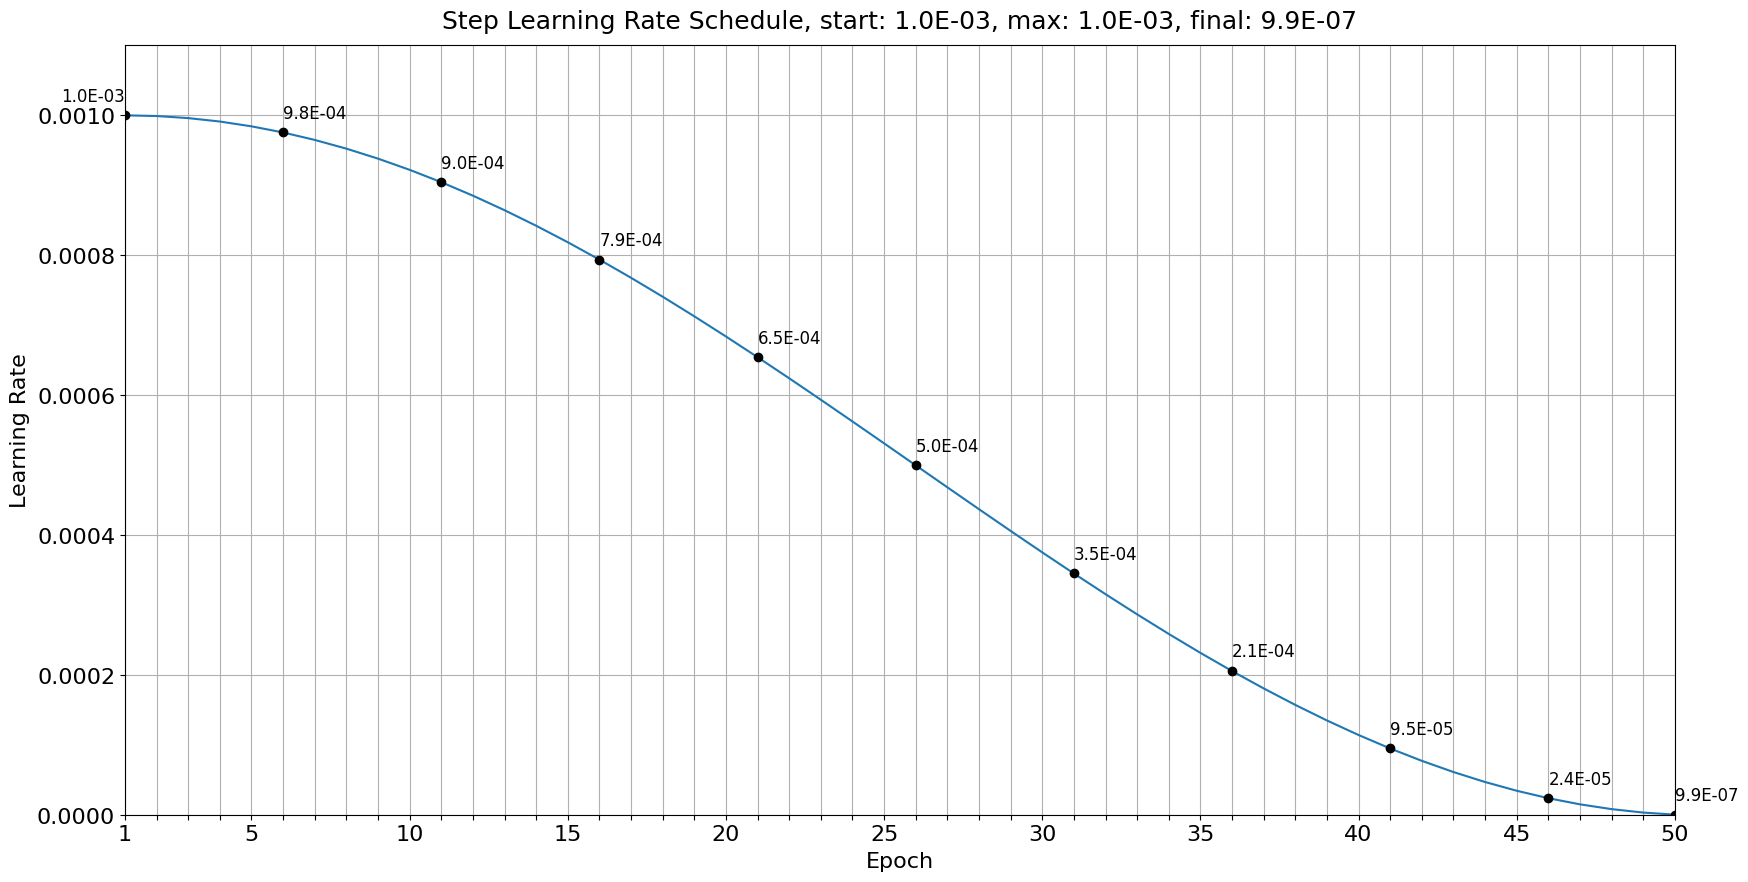

In [47]:
def plot_lr_schedule(lr_schedule, epochs):
    fig = plt.figure(figsize=(20, 10))
    plt.plot([None] + lr_schedule + [None])
    # X Labels
    x = np.arange(1, epochs + 1)
    x_axis_labels = [i if epochs <= 40 or i % 5 == 0 or i == 1 else None for i in range(1, epochs + 1)]
    plt.xlim([1, epochs])
    plt.xticks(x, x_axis_labels) # set tick step to 1 and let x axis start at 1
    
    plt.ylim([0, max(lr_schedule) * 1.1])
    
    # Title
    schedule_info = f'start: {lr_schedule[0]:.1E}, max: {max(lr_schedule):.1E}, final: {lr_schedule[-1]:.1E}'
    plt.title(f'Step Learning Rate Schedule, {schedule_info}', size=18, pad=12)
    
    # Plot Learning Rates
    for x, val in enumerate(lr_schedule):
        if epochs <= 40 or x % 5 == 0 or x is epochs - 1:
            if x < len(lr_schedule) - 1:
                if lr_schedule[x - 1] < val:
                    ha = 'right'
                else:
                    ha = 'left'
            elif x == 0:
                ha = 'right'
            else:
                ha = 'left'
            plt.plot(x + 1, val, 'o', color='black');
            offset_y = (max(lr_schedule) - min(lr_schedule)) * 0.02
            plt.annotate(f'{val:.1E}', xy=(x + 1, val + offset_y), size=12, ha=ha)
    
    plt.xlabel('Epoch', size=16, labelpad=5)
    plt.ylabel('Learning Rate', size=16, labelpad=5)
    plt.grid()
    plt.show()

# Learning rate for encoder
LR_SCHEDULE = [lrfn(step, num_warmup_steps=N_WARMUP_EPOCHS, lr_max=LR_MAX, num_cycles=0.50) for step in range(N_EPOCHS)]
# Plot Learning Rate Schedule
plot_lr_schedule(LR_SCHEDULE, epochs=N_EPOCHS)
# Learning Rate Callback
lr_callback = tf.keras.callbacks.LearningRateScheduler(lambda step: LR_SCHEDULE[step], verbose=1)

# Weight Decay Callback

In [48]:
# Custom callback to update weight decay with learning rate
class WeightDecayCallback(tf.keras.callbacks.Callback):
    def __init__(self, wd_ratio=WD_RATIO):
        self.step_counter = 0
        self.wd_ratio = wd_ratio
    
    def on_epoch_begin(self, epoch, logs=None):
        model.optimizer.weight_decay = model.optimizer.learning_rate * self.wd_ratio
        print(f'learning rate: {model.optimizer.learning_rate.numpy():.2e}, weight decay: {model.optimizer.weight_decay.numpy():.2e}') 

# Performance Benchmark

In [49]:
# Custom callback to update weight decay with learning rate
class WeightDecayCallback(tf.keras.callbacks.Callback):
    def __init__(self, wd_ratio=WD_RATIO):
        self.step_counter = 0
        self.wd_ratio = wd_ratio
    
    def on_epoch_begin(self, epoch, logs=None):
        model.optimizer.weight_decay = model.optimizer.learning_rate * self.wd_ratio
        print(f'learning rate: {model.optimizer.learning_rate.numpy():.2e}, weight decay: {model.optimizer.weight_decay.numpy():.2e}') 

# Training

In [50]:
if USE_VAL:
    # Verify val dataset covers all signs
    print(f'# Unique Signs in Validation Set: {pd.Series(y_val).nunique()}')
    # Value Counts
    display(pd.Series(y_val).value_counts().to_frame('Count').iloc[[1,2,3,-3,-2,-1]]) 

# Unique Signs in Validation Set: 250


,Count
111,28
158,24
136,24
61,12
108,11
249,11


In [51]:
# Sanity Check
if TRAIN_MODEL and USE_VAL:
    _ = model.evaluate(*validation_data, verbose=2) 

/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


146/146 - 23s - 154ms/step - acc: 0.0041 - loss: 6.6196 - top5_acc: 0.0204


In [52]:
# Ensure validation labels are one-hot for CCE\n
if TRAIN_MODEL and USE_VAL:
    try:
        # Assuming validation_data is tuple (X, y)\n
        if isinstance(validation_data, tuple) or isinstance(validation_data, list):
            val_inputs, val_labels = validation_data
            if len(val_labels.shape) == 1:
                print('Converting validation labels to One-Hot')
                val_labels_oh = tf.one_hot(val_labels, NUM_CLASSES)
                validation_data = (val_inputs, val_labels_oh)
    except Exception as e:
        print(f'Warning: Could not auto-convert validation labels: {e}')

In [53]:
if TRAIN_MODEL:
    tf.keras.backend.clear_session()

    steps_per_epoch = len(X_train) // (NUM_CLASSES * BATCH_ALL_SIGNS_N)
    
    # Create model with optimized dimension
    core_model = get_model(dim=256)  # Increased capacity
    core_model.summary()

    model = core_model

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', 
        patience=15,  # Increased patience
        restore_best_weights=True, 
        verbose=1
    )

    history = model.fit(
        x=get_train_batch_all_signs(X_train, y_train, NON_EMPTY_FRAME_IDXS_TRAIN),
        steps_per_epoch=steps_per_epoch,
        epochs=N_EPOCHS,
        validation_data=validation_data,
        callbacks=[
            early_stopping,
            lr_callback,
            WeightDecayCallback(),
        ],
        verbose=2,
    ) 

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ frames (InputLayer) │ (None, 64, 66, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ slice_xy (Lambda)   │ (None, 64, 66, 2) │          0 │ frames[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ slice_lips_raw      │ (None, 64, 40, 2) │          0 │ slice_xy[0][0]    │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ slice_left_hand_raw │ (None, 64, 21, 2) │          0 │ slice_xy[0][0]    │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ slice_pose_raw      │ (None, 64, 5, 2)  │          0 │ slice_xy[0][0]    │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ [(None, 64, 40,   │          0 │ slice_lips_raw[0… │
│ (Augmentation)      │ 2), (None, 64,    │            │ slice_left_hand_… │
│                     │ 21, 2), (None,    │            │ slice_pose_raw[0… │
│                     │ 64, 5, 2)]        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalize_left_hand │ (None, 64, 21, 2) │          0 │ augmentation[0][… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalize_pose      │ (None, 64, 5, 2)  │          0 │ augmentation[0][… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalize_lips      │ (None, 64, 40, 2) │          0 │ augmentation[0][… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_left_hand   │ (None, 64, 42)    │          0 │ normalize_left_h… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_pose        │ (None, 64, 10)    │          0 │ normalize_pose[0… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_lips        │ (None, 64, 80)    │          0 │ normalize_lips[0… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ motion_left_hand    │ (None, 64, 126)   │          0 │ reshape_left_han… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_left_hand   │ (None, 64, 441)   │          0 │ reshape_left_han… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ motion_pose         │ (None, 64, 30)    │          0 │ reshape_pose[0][… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_pose        │ (None, 64, 25)    │          0 │ reshape_pose[0][… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ motion_lips         │ (None, 64, 240)   │          0 │ reshape_lips[0][

 Total params: 2,681,594 (10.23 MB)

 Trainable params: 2,672,890 (10.20 MB)

 Non-trainable params: 8,704 (34.00 KB)


Epoch 1: LearningRateScheduler setting learning rate to 0.001.
learning rate: 1.00e-03, weight decay: 5.00e-05
Epoch 1/50
80/80 - 162s - 2s/step - acc: 0.0117 - loss: 5.4787 - top5_acc: 0.0487 - val_acc: 0.0301 - val_loss: 5.2272 - val_top5_acc: 0.1074 - learning_rate: 1.0000e-03

Epoch 2: LearningRateScheduler setting learning rate to 0.0009990133642141358.
learning rate: 9.99e-04, weight decay: 5.00e-05
Epoch 2/50
80/80 - 162s - 2s/step - acc: 0.0740 - loss: 4.7063 - top5_acc: 0.2359 - val_acc: 0.1933 - val_loss: 3.8840 - val_top5_acc: 0.4725 - learning_rate: 9.9901e-04

Epoch 3: LearningRateScheduler setting learning rate to 0.000996057350657239.
learning rate: 9.96e-04, weight decay: 4.98e-05
Epoch 3/50
80/80 - 163s - 2s/step - acc: 0.1969 - loss: 3.9834 - top5_acc: 0.4550 - val_acc: 0.3381 - val_loss: 3.1170 - val_top5_acc: 0.6482 - learning_rate: 9.9606e-04

Epoch 4: LearningRateScheduler setting learning rate to 0.0009911436253643444.
learning rate: 9.91e-04, weight decay: 4.96

In [54]:
# Save Model Weights
model.save_weights('model.weights.h5') 

In [55]:
if USE_VAL:
    # val dataset predictions
    y_val_pred = model.predict({ 'frames': X_val, 'non_empty_frame_idxs': NON_EMPTY_FRAME_IDXS_VAL }, verbose=2).argmax(axis=1)
    # Label
    labels = [ORD2SIGN.get(i).replace(' ', '_') for i in range(NUM_CLASSES)]  

146/146 - 18s - 120ms/step


In [56]:
# Test set Evaluation
if X_test is not None and y_test is not None:
    print("=" * 50)
    print("EVALUATING ON HOLDOUT TEST SET")
    print("=" * 50)
    
    # Prepare test data in the same format
    X_test_batch = np.zeros([len(y_test), INPUT_SIZE, N_COLS, N_DIMS], dtype=np.float32)
    for i in range(len(y_test)):
        X_test_batch[i] = X_test[i]
    
    # One-hot encode test labels
    y_test_onehot = np.zeros([len(y_test), NUM_CLASSES], dtype=np.float32)
    for i, label in enumerate(y_test):
        y_test_onehot[i, int(label)] = 1.0
    
    test_data = (
        {'frames': X_test_batch, 'non_empty_frame_idxs': NON_EMPTY_FRAME_IDXS_TEST},
        y_test_onehot
    )
    
    # Evaluate
    results = model.evaluate(test_data[0], test_data[1], verbose=1)
    
    print("\n" + "=" * 50)
    print(f"TEST LOSS:     {results[0]:.4f}")
    print(f"TEST ACCURACY: {results[1]*100:.2f}%")
    print("=" * 50)
    
    # Optional: Get predictions for confusion matrix
    predictions = model.predict(test_data[0], verbose=1)
    y_pred = np.argmax(predictions, axis=1)
    y_true = np.argmax(y_test_onehot, axis=1)
    
    # Top-5 accuracy
    top5_correct = 0
    for i in range(len(y_true)):
        top5_preds = np.argsort(predictions[i])[-5:]
        if y_true[i] in top5_preds:
            top5_correct += 1
    top5_acc = top5_correct / len(y_true)
    print(f"TOP-5 ACCURACY: {top5_acc*100:.2f}%")
else:
    print("Test set not available. Run preprocessing with PREPROCESS_DATA=True to generate.")

EVALUATING ON HOLDOUT TEST SET
300/300 ━━━━━━━━━━━━━━━━━━━━ 43s 145ms/step - acc: 0.7353 - loss: 1.4440 - top5_acc: 0.9268

TEST LOSS:     1.4430
TEST ACCURACY: 73.78%
300/300 ━━━━━━━━━━━━━━━━━━━━ 37s 124ms/step
TOP-5 ACCURACY: 92.51%


# Landmark Attention Weights

In [57]:
embedding_layer = None
for layer in model.layers:
    if 'embedding' in layer.name:
        embedding_layer = layer
        break

if embedding_layer is None:
    raise RuntimeError("Embedding layer not found in the model.")

landmark_weights_var = getattr(embedding_layer, 'landmark_weights', None)

if landmark_weights_var is None:
    raise RuntimeError("'landmark_weights' attribute not found in the embedding layer.")

# Convert to numpy and apply softmax for readable weights
import scipy

weights = scipy.special.softmax(landmark_weights_var.numpy())

# Print weights
landmarks = ['lips_embedding', 'left_hand_embedding', 'pose_embedding']

for w, lm in zip(weights, landmarks):
    print(f'{lm} weight: {(w * 100):.1f}%') 

lips_embedding weight: 33.3%
left_hand_embedding weight: 33.3%
pose_embedding weight: 33.3%


# Classification Report

In [58]:
def print_classification_report():
    # Classification report for all signs
    classification_report = sklearn.metrics.classification_report(
            y_val,
            y_val_pred,
            target_names=labels,
            output_dict=True,
        )
    # Round Data for better readability
    classification_report = pd.DataFrame(classification_report).T
    classification_report = classification_report.round(2)
    classification_report = classification_report.astype({
            'support': np.uint16,
        })
    # Add signs
    classification_report['sign'] = [e if e in SIGN2ORD else -1 for e in classification_report.index]
    classification_report['sign_ord'] = classification_report['sign'].apply(SIGN2ORD.get).fillna(-1).astype(np.int16)
    # Sort on F1-score
    classification_report = pd.concat((
        classification_report.head(NUM_CLASSES).sort_values('f1-score', ascending=False),
        classification_report.tail(3),
    ))

    pd.options.display.max_rows = 999
    display(classification_report)

In [59]:
if USE_VAL:
    print_classification_report() 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,precision,recall,f1-score,support,sign,sign_ord
horse,0.95,1.00,0.98,21,horse,119
airplane,1.00,0.94,0.97,18,airplane,2
frog,0.94,1.00,0.97,17,frog,90
brown,1.00,0.95,0.97,20,brown,31
shoe,0.95,1.00,0.97,19,shoe,196
shhh,1.00,0.95,0.97,20,shhh,194
garbage,0.92,1.00,0.96,12,garbage,91
zipper,0.92,1.00,0.96,11,zipper,249
fireman,0.91,1.00,0.95,20,fireman,82
cloud,1.00,0.90,0.95,20,cloud,48


# Training History

In [60]:
def plot_history_metric(metric, f_best=np.argmax, ylim=None, yscale=None, yticks=None):
    plt.figure(figsize=(20, 10))
    
    values = history.history[metric]
    N_EPOCHS = len(values)
    val = 'val' in ''.join(history.history.keys())
    # Epoch ticks
    if N_EPOCHS <= 20:
        x = np.arange(1, N_EPOCHS + 1)
    else:
        x = [1, 5] + [10 + 5 * idx for idx in range((N_EPOCHS - 10) // 5 + 1)]

    x_ticks = np.arange(1, N_EPOCHS+1)

    # Validation
    if val:
        val_values = history.history[f'val_{metric}']
        val_argmin = f_best(val_values)
        plt.plot(x_ticks, val_values, label=f'val')

    # summarize history for accuracy
    plt.plot(x_ticks, values, label=f'train')
    argmin = f_best(values)
    plt.scatter(argmin + 1, values[argmin], color='red', s=75, marker='o', label=f'train_best')
    if val:
        plt.scatter(val_argmin + 1, val_values[val_argmin], color='purple', s=75, marker='o', label=f'val_best')

    plt.title(f'Model {metric}', fontsize=24, pad=10)
    plt.ylabel(metric, fontsize=20, labelpad=10)

    if ylim:
        plt.ylim(ylim)

    if yscale is not None:
        plt.yscale(yscale)
        
    if yticks is not None:
        plt.yticks(yticks, fontsize=16)

    plt.xlabel('epoch', fontsize=20, labelpad=10)        
    plt.tick_params(axis='x', labelsize=8)
    plt.xticks(x, fontsize=16) # set tick step to 1 and let x axis start at 1
    plt.yticks(fontsize=16)
    
    plt.legend(prop={'size': 10})
    plt.grid()
    plt.show()

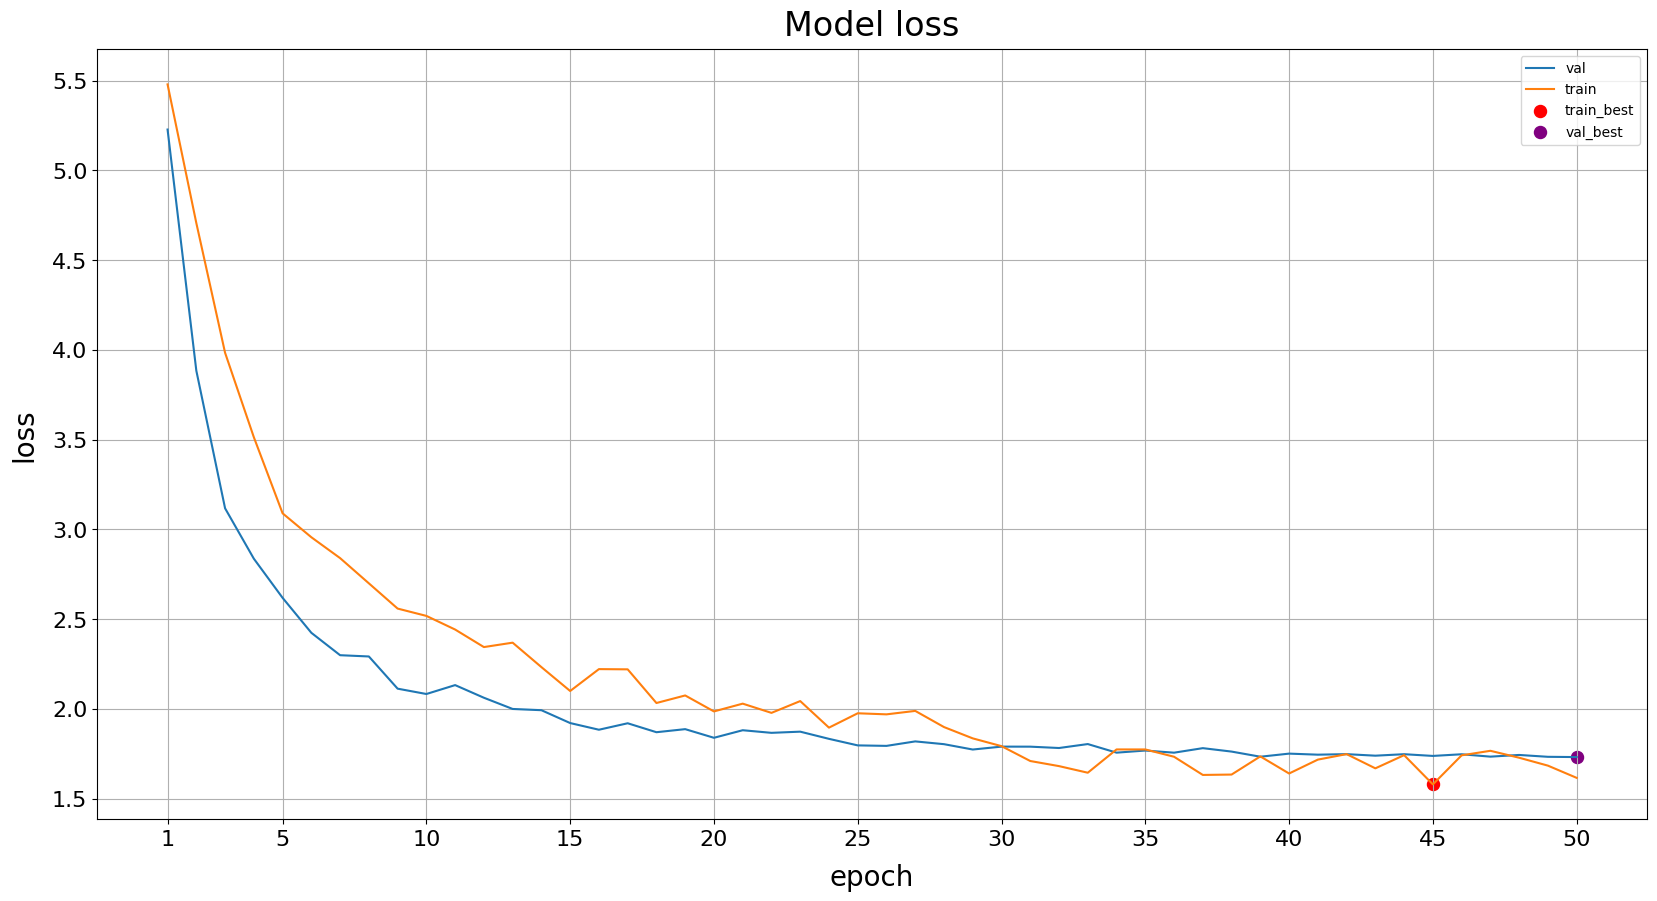

In [61]:
if TRAIN_MODEL:
    plot_history_metric('loss', f_best=np.argmin) 

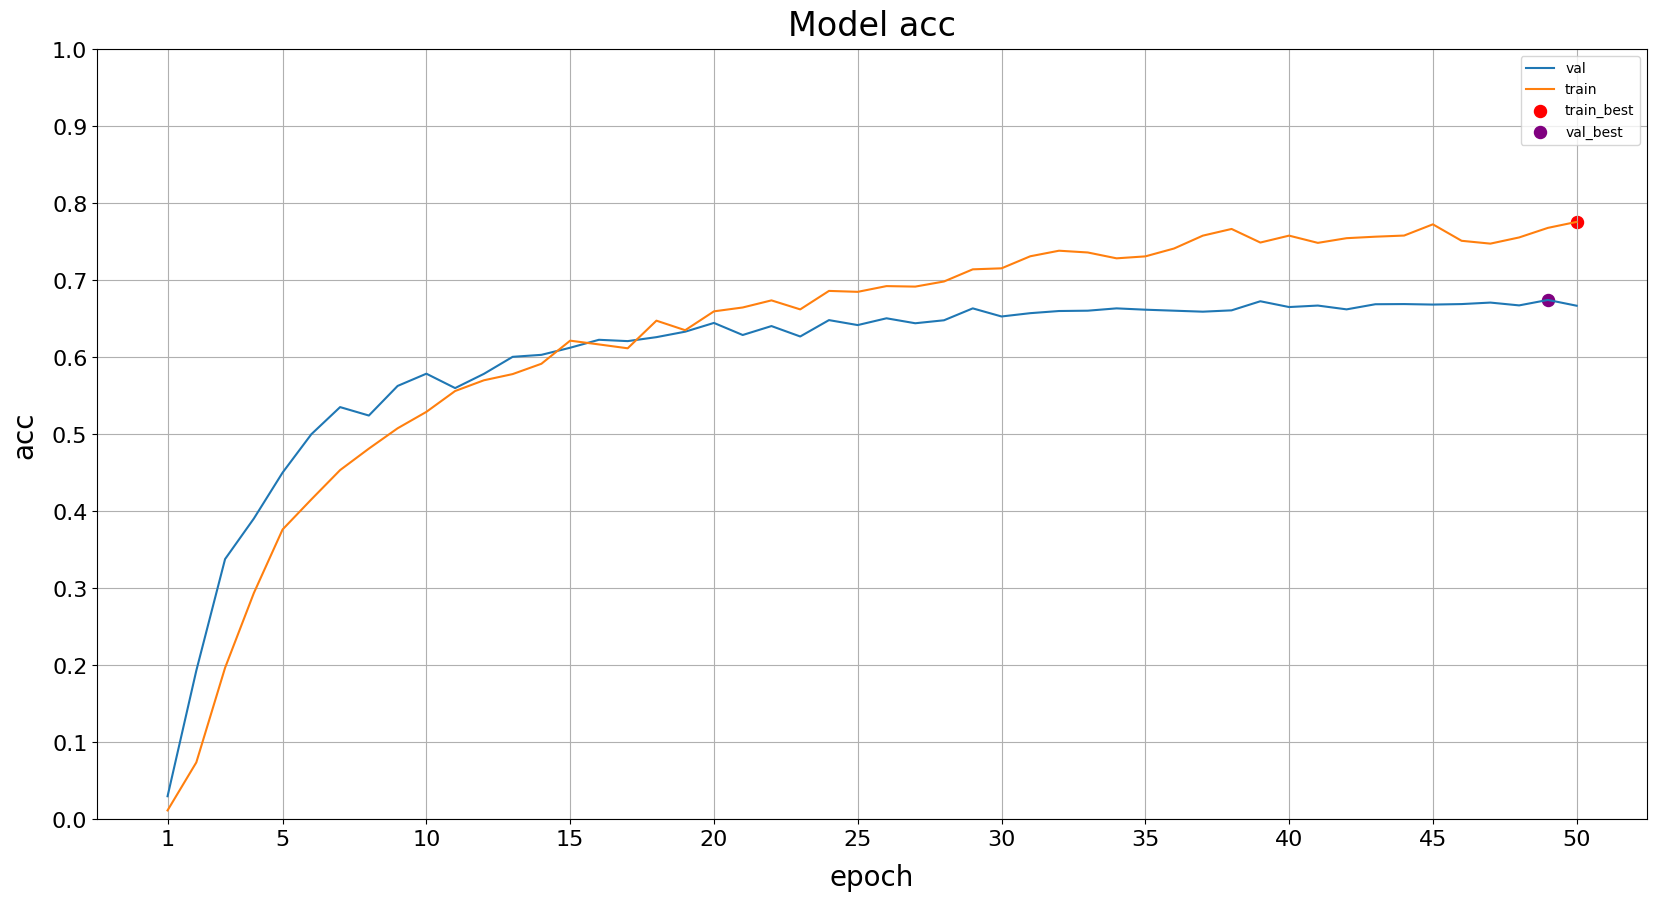

In [62]:
if TRAIN_MODEL:
    plot_history_metric('acc', ylim=[0,1], yticks=np.arange(0.0, 1.1, 0.1)) 

# TFLite Model Conversion

In [63]:
class TFLiteModel(tf.Module):
    def __init__(self, model):
        super(TFLiteModel, self).__init__()
        self.model = model
        
        # Initialize Normalization Correction (Copied from PreprocessLayer)
        normalisation_correction = tf.constant([
                    # Add 0.50 to left hand (original right hand) and substract 0.50 of right hand (original left hand)
                    [0] * len(LIPS_IDXS) + [0.50] * len(LEFT_HAND_IDXS) + [0.50] * len(POSE_IDXS),
                    # Y coordinates stay intact
                    [0] * len(LANDMARK_IDXS_LEFT_DOMINANT0),
                    # Z coordinates stay intact
                    [0] * len(LANDMARK_IDXS_LEFT_DOMINANT0),
                ],
                dtype=tf.float32,
            )
        self.normalisation_correction = tf.transpose(normalisation_correction, [1,0])

    def pad_edge(self, t, repeats, side):
        if side == 'LEFT':
            return tf.concat((tf.repeat(t[:1], repeats=repeats, axis=0), t), axis=0)
        elif side == 'RIGHT':
            return tf.concat((t, tf.repeat(t[-1:], repeats=repeats, axis=0)), axis=0)

    @tf.function(input_signature=[tf.TensorSpec(shape=[None, 543, 3], dtype=tf.float32, name='inputs')])
    def __call__(self, data0):
        # Number of Frames in Video
        N_FRAMES0 = tf.shape(data0)[0]
        
        # Find dominant hand by comparing summed absolute coordinates
        left_hand_sum = tf.math.reduce_sum(tf.where(tf.math.is_nan(tf.gather(data0, LEFT_HAND_IDXS0, axis=1)), 0, 1))
        right_hand_sum = tf.math.reduce_sum(tf.where(tf.math.is_nan(tf.gather(data0, RIGHT_HAND_IDXS0, axis=1)), 0, 1))
        left_dominant = left_hand_sum >= right_hand_sum
        
        # Count non-NaN Hand values in each frame for the dominant hand
        if left_dominant:
            frames_hands_non_nan_sum = tf.math.reduce_sum(
                    tf.where(tf.math.is_nan(tf.gather(data0, LEFT_HAND_IDXS0, axis=1)), 0, 1),
                    axis=[1, 2],
                )
        else:
            frames_hands_non_nan_sum = tf.math.reduce_sum(
                    tf.where(tf.math.is_nan(tf.gather(data0, RIGHT_HAND_IDXS0, axis=1)), 0, 1),
                    axis=[1, 2],
                )
        
        # Find frames indices with coordinates of the dominant hand
        non_empty_frames_idxs = tf.where(frames_hands_non_nan_sum > 0)
        non_empty_frames_idxs = tf.squeeze(non_empty_frames_idxs, axis=1)
        # Filter frames
        data = tf.gather(data0, non_empty_frames_idxs, axis=0)
        
        # Cast Indices in float32 to be compatible with Tensorflow Lite
        non_empty_frames_idxs = tf.cast(non_empty_frames_idxs, tf.float32)
        # Normalize to start with 0
        non_empty_frames_idxs -= tf.reduce_min(non_empty_frames_idxs)
        
        # Number of Frames in Filtered Video
        N_FRAMES = tf.shape(data)[0]
        
        # Gather Relevant Landmark Columns
        if left_dominant:
            data = tf.gather(data, LANDMARK_IDXS_LEFT_DOMINANT0, axis=1)
        else:
            data = tf.gather(data, LANDMARK_IDXS_RIGHT_DOMINANT0, axis=1)
            data = (
                    self.normalisation_correction + (
                        (data - self.normalisation_correction) * tf.where(self.normalisation_correction != 0, -1.0, 1.0))
                )
        
        # Video fits in INPUT_SIZE
        if N_FRAMES < INPUT_SIZE:
            # Pad With -1 to indicate padding
            non_empty_frames_idxs = tf.pad(non_empty_frames_idxs, [[0, INPUT_SIZE-N_FRAMES]], constant_values=-1)
            # Pad Data With Zeros
            data = tf.pad(data, [[0, INPUT_SIZE-N_FRAMES], [0,0], [0,0]], constant_values=0)
            # Fill NaN Values With 0
            data = tf.where(tf.math.is_nan(data), 0.0, data)
        # Video needs to be downsampled to INPUT_SIZE
        else:
            # Repeat
            if N_FRAMES < INPUT_SIZE**2:
                repeats = tf.math.floordiv(INPUT_SIZE * INPUT_SIZE, N_FRAMES0)
                data = tf.repeat(data, repeats=repeats, axis=0)
                non_empty_frames_idxs = tf.repeat(non_empty_frames_idxs, repeats=repeats, axis=0)

            # Pad To Multiple Of Input Size
            pool_size = tf.math.floordiv(len(data), INPUT_SIZE)
            if tf.math.mod(len(data), INPUT_SIZE) > 0:
                pool_size += 1

            if pool_size == 1:
                pad_size = (pool_size * INPUT_SIZE) - len(data)
            else:
                pad_size = (pool_size * INPUT_SIZE) % len(data)

            # Pad Start/End with Start/End value
            pad_left = tf.math.floordiv(pad_size, 2) + tf.math.floordiv(INPUT_SIZE, 2)
            pad_right = tf.math.floordiv(pad_size, 2) + tf.math.floordiv(INPUT_SIZE, 2)
            if tf.math.mod(pad_size, 2) > 0:
                pad_right += 1

            # Pad By Concatenating Left/Right Edge Values
            data = self.pad_edge(data, pad_left, 'LEFT')
            data = self.pad_edge(data, pad_right, 'RIGHT')

            # Pad Non Empty Frame Indices
            non_empty_frames_idxs = self.pad_edge(non_empty_frames_idxs, pad_left, 'LEFT')
            non_empty_frames_idxs = self.pad_edge(non_empty_frames_idxs, pad_right, 'RIGHT')

            # Reshape to Mean Pool
            data = tf.reshape(data, [INPUT_SIZE, -1, N_COLS, N_DIMS])
            non_empty_frames_idxs = tf.reshape(non_empty_frames_idxs, [INPUT_SIZE, -1])

            # Mean Pool
            data = tf.math.divide_no_nan(tf.reduce_sum(tf.where(tf.math.is_nan(data), 0.0, data), axis=1), tf.reduce_sum(tf.cast(tf.math.is_finite(data), tf.float32), axis=1))
            non_empty_frames_idxs = tf.math.divide_no_nan(tf.reduce_sum(tf.where(tf.math.is_nan(non_empty_frames_idxs), 0.0, non_empty_frames_idxs), axis=1), tf.reduce_sum(tf.cast(tf.math.is_finite(non_empty_frames_idxs), tf.float32), axis=1))

            # Fill NaN Values With 0
            data = tf.where(tf.math.is_nan(data), 0.0, data)
            
        # --- Preprocessing Done, now Inference ---
        x = data
        
        # Make Prediction (Add batch dim matching inputs)
        # Note: x is (64, 66, 3), model needs (Batch, 64, 66, 3)
        outputs = self.model({'frames':tf.expand_dims(x, axis=0), 'non_empty_frame_idxs': tf.expand_dims(non_empty_frames_idxs, axis=0)})[0]

        # Return Dictionary
        return {'outputs': outputs}

tflite_keras_model = TFLiteModel(model)

In [64]:
import json
# Get concrete function
concrete_func = tflite_keras_model.__call__.get_concrete_function()

# Convert from concrete function
converter = tf.lite.TFLiteConverter.from_concrete_functions([concrete_func], tflite_keras_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
tflite_model = converter.convert()

# Save TFLite Model
with open('inference.tflite', 'wb') as f:
    f.write(tflite_model)
    
# Zip for Submission
import zipfile

inference_args = {
    "selected_columns": [i for i in range(543)],
    "columns": ["x", "y", "z"]
}

with open('inference_args.json', 'w') as f:
    json.dump(inference_args, f)

with zipfile.ZipFile('submission.zip', 'w') as z:
    z.write('inference.tflite')
    z.write('inference_args.json')
    
print('Submission created: submission.zip')

I0000 00:00:1768781856.595236      26 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1768781856.595426      26 single_machine.cc:374] Starting new session
I0000 00:00:1768781856.596520      26 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
W0000 00:00:1768781857.734354      26 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1768781857.734391      26 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


Submission created: submission.zip
